### **KLASIFIKASI POLA AKTIVITAS FISIK TERHADAP TINGKAT KEBUGARAN**

Dataset: Fitnes Tracker Dataset


In [ ]:
!pip install imbalanced-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    silhouette_score, davies_bouldin_score
)
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA # Added this import

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', font_scale=1.1)

print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


In [ ]:
from google.colab import files
import io

uploaded = files.upload()   # Upload file CSV dari Kaggle
filename = list(uploaded.keys())[0]
df_raw   = pd.read_csv(io.BytesIO(uploaded[filename]))

# Bersihkan nama kolom dari spasi/tab tersembunyi
df_raw.columns = df_raw.columns.str.strip()

print(f'✅ Dataset "{filename}" berhasil dimuat!')
print(f'   Shape: {df_raw.shape[0]} baris × {df_raw.shape[1]} kolom')
print(f'   Kolom: {df_raw.columns.tolist()}')
display(df_raw.head(3))

Saving fitness_data_clean.csv to fitness_data_clean.csv
✅ Dataset "fitness_data_clean.csv" berhasil dimuat!
   Shape: 2325 baris × 9 kolom
   Kolom: ['Calories_Burned', 'Fat_Percentage', 'BMI', 'Weight (kg)', 'Height (m)', 'Session_Duration (hours)', 'Age', 'Avg_BPM', 'Experience_Level']


,Calories_Burned,Fat_Percentage,BMI,Weight (kg),Height (m),Session_Duration (hours),Age,Avg_BPM,Experience_Level
0,0.276351,0.112,0.083980,0.575566,0.72,0.413333,0.390244,0.653061,2.0
1,0.358108,0.716,0.893390,0.550917,0.66,0.333333,0.195122,0.734694,2.0
2,0.929054,0.748,0.017302,0.305654,0.70,0.493333,0.097561,0.938776,2.0


In [ ]:
# Bersihkan karakter tersembunyi (tab, newline) di semua nilai
df = df_raw.copy()
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].astype(str).str.strip().str.replace('\t','').str.replace('\n','')

# Paksa semua kolom numerik (kecuali Gender & Workout_Type) ke float
skip_encode = ['Gender', 'Workout_Type']
for col in df.columns:
    if col not in skip_encode:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'✅ Data berhasil dibersihkan!')
print(df.dtypes)

✅ Data berhasil dibersihkan!
Calories_Burned             float64
Fat_Percentage              float64
BMI                         float64
Weight (kg)                 float64
Height (m)                  float64
Session_Duration (hours)    float64
Age                         float64
Avg_BPM                     float64
Experience_Level            float64
dtype: object


In [ ]:
# ── Hitung Fitness Score dari 7 indikator kebugaran ──────────
sc_tmp = MinMaxScaler()

# Fitur yang POSITIF terhadap kebugaran
fitur_positif = [
    'Session_Duration (hours)',
    'Calories_Burned'
    # 'Workout_Frequency (days/week)', # Removed: not in DataFrame
    # 'Water_Intake (liters)'          # Removed: not in DataFrame
]

# Fitur yang NEGATIF terhadap kebugaran (dibalik: 1 - nilai)
fitur_negatif = [
    # 'Resting_BPM',                   # Removed: not in DataFrame
    'Fat_Percentage',
    'BMI'
]

df_tmp = df.copy()
df_tmp[fitur_positif] = sc_tmp.fit_transform(df_tmp[fitur_positif])
df_tmp[fitur_negatif] = 1 - sc_tmp.fit_transform(df_tmp[fitur_negatif])

# Skor gabungan = rata-rata semua komponen (bobot sama)
df['Fitness_Score'] = df_tmp[fitur_positif + fitur_negatif].mean(axis=1)

# Bagi menjadi 3 kelas seimbang berdasarkan persentil 33% dan 66%
p33 = df['Fitness_Score'].quantile(0.33)
p66 = df['Fitness_Score'].quantile(0.66)

def buat_label(score):
    if score <= p33:
        return 'Rendah'
    elif score <= p66:
        return 'Sedang'
    else:
        return 'Tinggi'

df['Fitness_Level'] = df['Fitness_Score'].apply(buat_label)
TARGET_COL = 'Fitness_Level'
LABEL_NAMES = ['Rendah', 'Sedang', 'Tinggi']

print('✅ Label Fitness_Level berhasil dibuat!')
print(f'\n📊 Logika penentuan kategori:')
print(f'   Fitness Score ≤ {p33:.4f}            → Rendah')
print(f'   Fitness Score {p33:.4f} – {p66:.4f}  → Sedang')
print(f'   Fitness Score > {p66:.4f}            → Tinggi')
print(f'\n📊 Distribusi kelas:')
vc = df[TARGET_COL].value_counts()
for label in LABEL_NAMES:
    n = vc.get(label, 0)
    bar = '█' * int(n / vc.max() * 30)
    print(f'   {label:10s}: {n:4d} data  {bar}')

print(f'\n📋 Contoh 10 data dengan label:')
display(df[fitur_positif + fitur_negatif + ['Fitness_Score', 'Fitness_Level']].head(10).round(4))

✅ Label Fitness_Level berhasil dibuat!

📊 Logika penentuan kategori:
   Fitness Score ≤ 0.5005            → Rendah
   Fitness Score 0.5005 – 0.6046  → Sedang
   Fitness Score > 0.6046            → Tinggi

📊 Distribusi kelas:
   Rendah    :  767 data  █████████████████████████████
   Sedang    :  767 data  █████████████████████████████
   Tinggi    :  791 data  ██████████████████████████████

📋 Contoh 10 data dengan label:


,Session_Duration (hours),Calories_Burned,Fat_Percentage,BMI,Fitness_Score,Fitness_Level
0,0.4133,0.2764,0.112,0.0840,0.6234,Tinggi
1,0.3333,0.3581,0.716,0.8934,0.2705,Rendah
2,0.4933,0.9291,0.748,0.0173,0.6643,Tinggi
3,0.6333,0.2196,0.872,0.3397,0.4103,Rendah
4,0.7333,0.6642,0.656,0.3591,0.5956,Sedang
5,0.7467,0.4392,0.536,0.0295,0.6551,Tinggi
6,0.6400,0.6318,0.076,0.2448,0.7377,Tinggi
7,0.7533,0.3554,0.064,0.2887,0.6890,Tinggi
8,0.1800,0.3372,0.712,1.0000,0.2013,Rendah
9,1.0000,0.6270,0.820,0.0000,0.7018,Tinggi


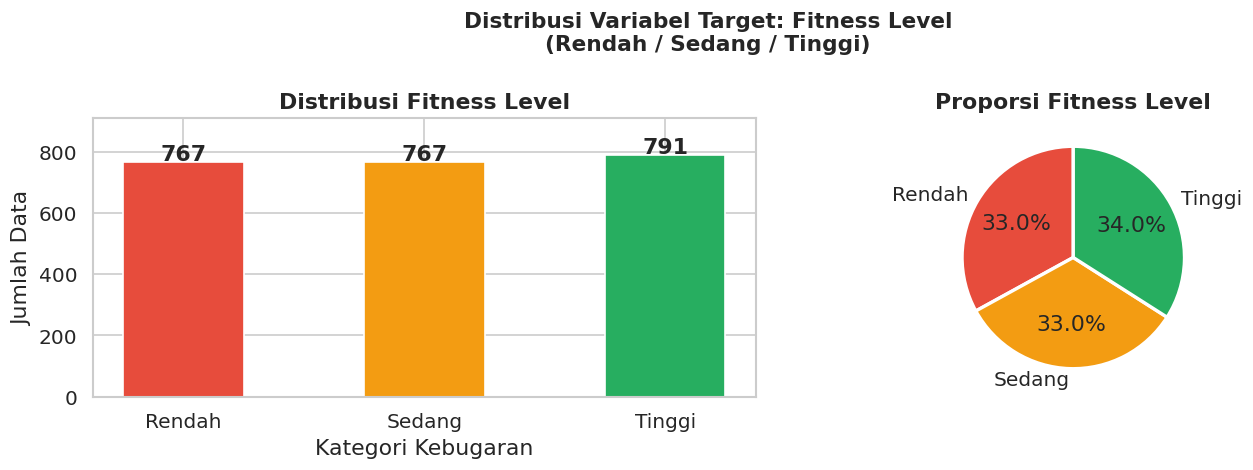

In [ ]:
# ── 4.1 Distribusi Target ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#E74C3C', '#F39C12', '#27AE60']
counts = [vc.get(l, 0) for l in LABEL_NAMES]

axes[0].bar(LABEL_NAMES, counts, color=colors, edgecolor='white', width=0.5)
for i, v in enumerate(counts):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[0].set_title('Distribusi Fitness Level', fontweight='bold')
axes[0].set_xlabel('Kategori Kebugaran')
axes[0].set_ylabel('Jumlah Data')
axes[0].set_ylim(0, max(counts) * 1.15)

axes[1].pie(counts, labels=LABEL_NAMES, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Fitness Level', fontweight='bold')

plt.suptitle('Distribusi Variabel Target: Fitness Level\n(Rendah / Sedang / Tinggi)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('01_distribusi_target.png', bbox_inches='tight')
plt.show()

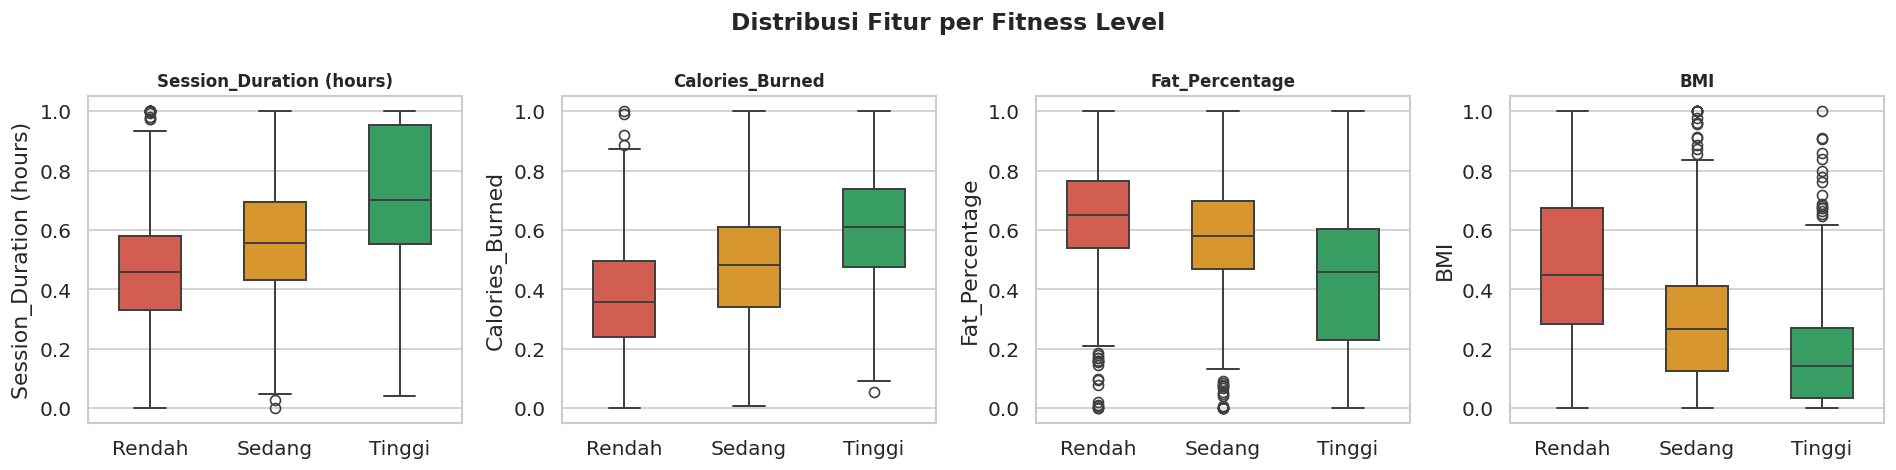

In [ ]:
# ── 4.2 Boxplot fitur utama per Fitness Level ────────────────
plot_cols = fitur_positif + fitur_negatif
n = len(plot_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()
palette = {'Rendah': '#E74C3C', 'Sedang': '#F39C12', 'Tinggi': '#27AE60'}

for i, col in enumerate(plot_cols):
    sns.boxplot(data=df, x=TARGET_COL, y=col,
                order=LABEL_NAMES, palette=palette, ax=axes[i],
                width=0.5, linewidth=1.2)
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur per Fitness Level', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_boxplot_per_level.png', bbox_inches='tight')
plt.show()

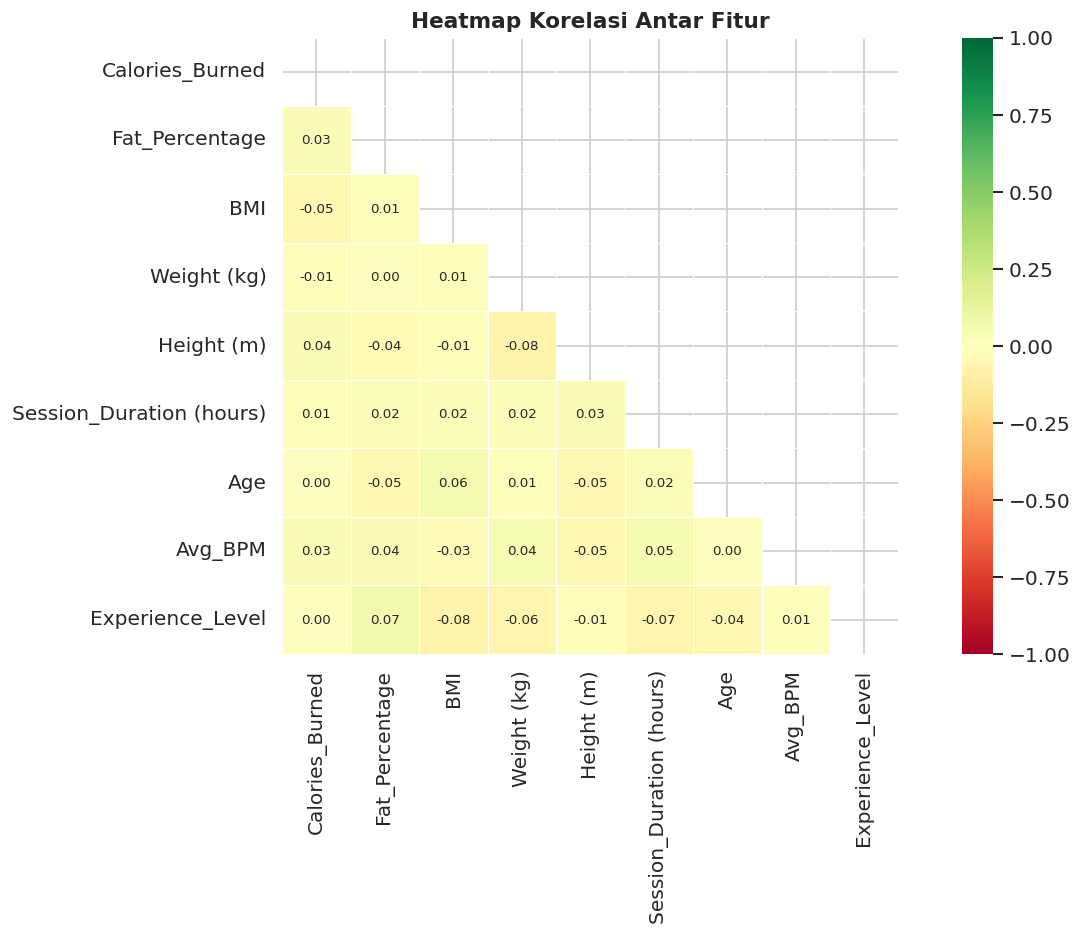

In [ ]:
# ── 4.3 Heatmap Korelasi ─────────────────────────────────────
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ['Fitness_Score']]

plt.figure(figsize=(12, 8))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, square=True, linewidths=0.5,
            annot_kws={'size': 8}, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('03_heatmap_korelasi.png', bbox_inches='tight')
plt.show()

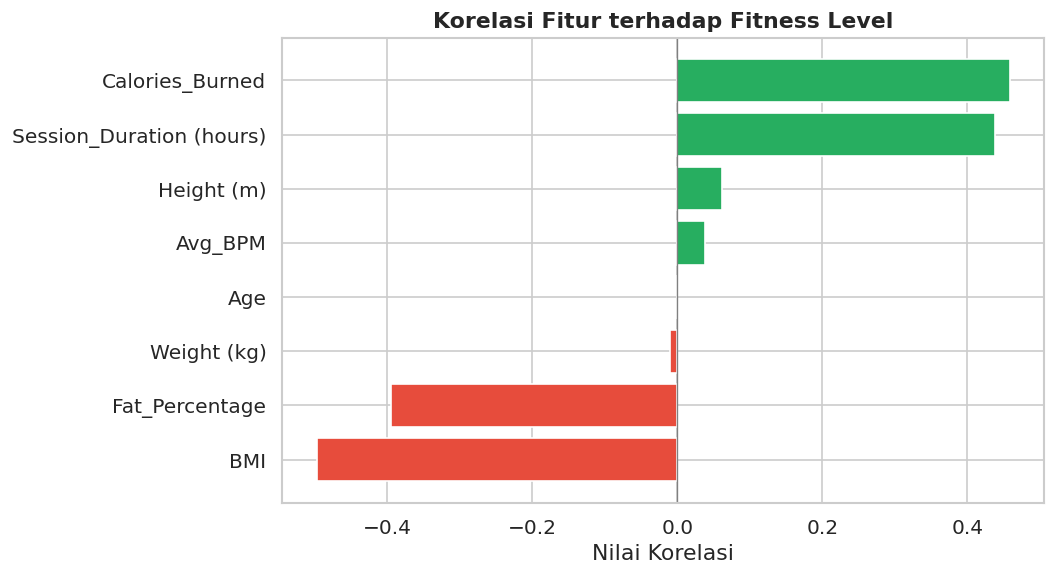

Korelasi fitur vs Fitness Level:
Calories_Burned             0.458
Session_Duration (hours)    0.438
Height (m)                  0.062
Avg_BPM                     0.039
Age                        -0.001
Weight (kg)                -0.010
Fat_Percentage             -0.394
BMI                        -0.497


In [ ]:
# ── 4.4 Korelasi fitur dengan Fitness_Score ──────────────────
fl_num = df[TARGET_COL].map({'Rendah': 1, 'Sedang': 2, 'Tinggi': 3})
corr_target = df[num_cols].corrwith(fl_num).drop('Experience_Level', errors='ignore')
corr_target = corr_target.sort_values(ascending=True)

colors_bar = ['#27AE60' if v > 0 else '#E74C3C' for v in corr_target.values]
plt.figure(figsize=(9, 5))
plt.barh(corr_target.index, corr_target.values, color=colors_bar, edgecolor='white')
plt.axvline(x=0, color='gray', linewidth=0.8)
plt.xlabel('Nilai Korelasi')
plt.title('Korelasi Fitur terhadap Fitness Level', fontweight='bold')
plt.tight_layout()
plt.savefig('04_korelasi_target.png', bbox_inches='tight')
plt.show()

print('Korelasi fitur vs Fitness Level:')
print(corr_target.sort_values(ascending=False).round(3).to_string())

In [ ]:
# ── 5.1 Cek & Tangani Missing Values ─────────────────────────
print('CEK MISSING VALUES')
print('=' * 45)
missing = df.isnull().sum()
missing = missing[missing > 0]

if missing.empty:
    print('✅ Tidak ada missing values!')
else:
    print(f'⚠️  Ditemukan {len(missing)} kolom dengan missing values:')
    print(missing)
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ['float64', 'int64']:
                df[col].fillna(df[col].median(), inplace=True)
                print(f'   → {col}: diisi median')
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)
                print(f'   → {col}: diisi modus')
    print('✅ Missing values berhasil ditangani!')

print(f'\nTotal missing values: {df.isnull().sum().sum()}')

CEK MISSING VALUES
✅ Tidak ada missing values!

Total missing values: 0


In [ ]:
# ── 5.2 Deteksi & Tangani Outlier (IQR Capping) ──────────────
# Metode CAPPING: nilai outlier di-clip ke batas IQR (tidak menghapus baris)
# Lebih aman karena tidak mengurangi jumlah data

print('PENANGANAN OUTLIER (IQR CAPPING)')
print('=' * 45)

fitur_num = [c for c in num_cols
             if c not in ['Fitness_Score', 'Experience_Level']]

n_outlier_total = 0
for col in fitur_num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    n_outlier_total += n_out
    if n_out > 0:
        df[col] = df[col].clip(lower=lo, upper=hi)
        print(f'   ⚠️  {col:35s}: {n_out} outlier di-cap')
    else:
        print(f'   ✅ {col:35s}: tidak ada outlier')

print(f'\n✅ Total outlier ditangani: {n_outlier_total}')
print(f'   Jumlah data tetap: {len(df)} baris (tidak ada yang dihapus)')

PENANGANAN OUTLIER (IQR CAPPING)
   ✅ Calories_Burned                    : tidak ada outlier
   ⚠️  Fat_Percentage                     : 75 outlier di-cap
   ⚠️  BMI                                : 51 outlier di-cap
   ⚠️  Weight (kg)                        : 29 outlier di-cap
   ✅ Height (m)                         : tidak ada outlier
   ✅ Session_Duration (hours)           : tidak ada outlier
   ✅ Age                                : tidak ada outlier
   ✅ Avg_BPM                            : tidak ada outlier

✅ Total outlier ditangani: 155
   Jumlah data tetap: 2325 baris (tidak ada yang dihapus)


In [ ]:
# ── 5.3 Encoding Fitur Kategorik ─────────────────────────────
le = LabelEncoder()

# if df['Gender'].dtype == object:
#     gender_classes = df['Gender'].unique()
#     df['Gender'] = le.fit_transform(df['Gender'])
#     print(f'✅ Gender di-encode: {dict(zip(gender_classes, le.transform(gender_classes)))}')

# if df['Workout_Type'].dtype == object:
#     wt_classes = sorted(df['Workout_Type'].unique())
#     le2 = LabelEncoder()
#     df['Workout_Type'] = le2.fit_transform(df['Workout_Type'])
#     print(f'✅ Workout_Type di-encode: {dict(zip(wt_classes, le2.transform(wt_classes)))}')

print('⚠️  Columns "Gender" and "Workout_Type" were not found in the DataFrame and thus not encoded.')

# Cek imbalance
vc = df[TARGET_COL].value_counts()
rasio = vc.min() / vc.max()
print(f'\nDistribusi kelas: {vc.to_dict()}')
print(f'Rasio min/max: {rasio:.2f}')
if rasio >= 0.7:
    print('✅ Data sudah seimbang — SMOTE tidak diperlukan')
else:
    print('⚠️  Data imbalance — pertimbangkan SMOTE')

⚠️  Columns "Gender" and "Workout_Type" were not found in the DataFrame and thus not encoded.

Distribusi kelas: {'Tinggi': 791, 'Rendah': 767, 'Sedang': 767}
Rasio min/max: 0.97
✅ Data sudah seimbang — SMOTE tidak diperlukan


In [ ]:
# ── Siapkan X dan y ──────────────────────────────────────────
# Fitur yang digunakan: semua kolom numerik kecuali kolom bantu
exclude = ['Experience_Level', 'Fitness_Level', 'Fitness_Score']
feature_cols = [c for c in df.select_dtypes(include=np.number).columns
                if c not in exclude]

X_raw = df[feature_cols].values
y_raw = df[TARGET_COL].values

print(f'Fitur awal ({len(feature_cols)}): {feature_cols}')
print(f'Shape X: {X_raw.shape}')

Fitur awal (8): ['Calories_Burned', 'Fat_Percentage', 'BMI', 'Weight (kg)', 'Height (m)', 'Session_Duration (hours)', 'Age', 'Avg_BPM']
Shape X: (2325, 8)


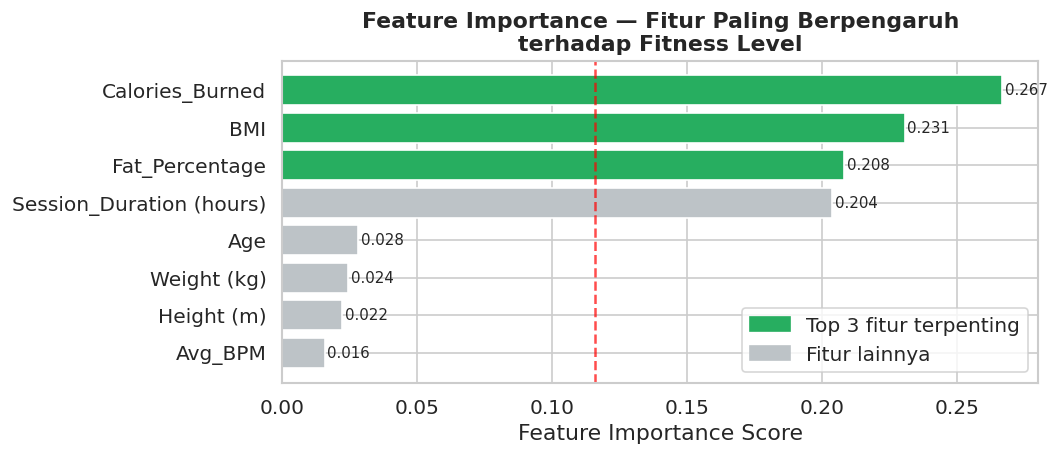


✅ Fitur terpilih (4): ['Session_Duration (hours)', 'Fat_Percentage', 'BMI', 'Calories_Burned']

📌 3 Fitur paling berpengaruh:
   1. Calories_Burned                    : 0.2670
   2. BMI                                : 0.2307
   3. Fat_Percentage                     : 0.2082


In [ ]:
# ── Normalisasi sementara untuk feature selection ─────────────
sc_tmp2 = MinMaxScaler()
X_tmp   = sc_tmp2.fit_transform(X_raw)

# Feature Importance awal dengan Decision Tree
dt_tmp = DecisionTreeClassifier(random_state=42)
dt_tmp.fit(X_tmp, y_raw)

imp_df = pd.DataFrame({
    'Fitur': feature_cols,
    'Importance': dt_tmp.feature_importances_
}).sort_values('Importance', ascending=True)

# Visualisasi
top3 = imp_df.nlargest(3, 'Importance')['Fitur'].tolist()
bar_colors = ['#27AE60' if f in top3 else '#BDC3C7' for f in imp_df['Fitur']]

plt.figure(figsize=(9, max(4, len(feature_cols) * 0.45)))
bars = plt.barh(imp_df['Fitur'], imp_df['Importance'],
                color=bar_colors, edgecolor='white')
plt.axvline(imp_df['Importance'].median(), color='red',
            linestyle='--', alpha=0.7, label='Median threshold')
for bar, val in zip(bars, imp_df['Importance']):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.xlabel('Feature Importance Score')
plt.title('Feature Importance — Fitur Paling Berpengaruh\nterhadap Fitness Level',
          fontweight='bold')
plt.legend(handles=[
    mpatches.Patch(color='#27AE60', label='Top 3 fitur terpenting'),
    mpatches.Patch(color='#BDC3C7', label='Fitur lainnya')
], loc='lower right')
plt.tight_layout()
plt.savefig('05_feature_importance.png', bbox_inches='tight')
plt.show()

# Pilih fitur di atas threshold
THRESHOLD = imp_df['Importance'].median()
selected  = imp_df[imp_df['Importance'] >= THRESHOLD]['Fitur'].tolist()
print(f'\n✅ Fitur terpilih ({len(selected)}): {selected}')
print(f'\n📌 3 Fitur paling berpengaruh:')
for i, (_, r) in enumerate(
    imp_df.sort_values('Importance', ascending=False).head(3).iterrows(), 1
):
    print(f'   {i}. {r["Fitur"]:35s}: {r["Importance"]:.4f}')

In [ ]:
# ── Ambil fitur terpilih & normalisasi final ──────────────────
sel_idx  = [feature_cols.index(f) for f in selected]
X_sel    = X_raw[:, sel_idx]

scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X_sel)
y        = y_raw.copy()

print(f'✅ Normalisasi MinMaxScaler selesai!')
print(f'   Fitur digunakan : {selected}')
print(f'   Shape X_scaled  : {X_scaled.shape}')
print(f'   Rentang nilai   : [{X_scaled.min():.2f}, {X_scaled.max():.2f}]')

✅ Normalisasi MinMaxScaler selesai!
   Fitur digunakan : ['Session_Duration (hours)', 'Fat_Percentage', 'BMI', 'Calories_Burned']
   Shape X_scaled  : (2325, 4)
   Rentang nilai   : [0.00, 1.00]


In [ ]:
# ── Split 80% latih / 20% uji ────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('✅ Pembagian data selesai!')
print(f'   Data latih : {len(X_train)} data (80%)')
print(f'   Data uji   : {len(X_test)} data (20%)')
print(f'\n   Distribusi data latih:')
for label in LABEL_NAMES:
    print(f'     {label}: {(y_train == label).sum()} data')
print(f'\n   Distribusi data uji:')
for label in LABEL_NAMES:
    print(f'     {label}: {(y_test == label).sum()} data')

✅ Pembagian data selesai!
   Data latih : 1860 data (80%)
   Data uji   : 465 data (20%)

   Distribusi data latih:
     Rendah: 613 data
     Sedang: 614 data
     Tinggi: 633 data

   Distribusi data uji:
     Rendah: 154 data
     Sedang: 153 data
     Tinggi: 158 data


Decission Tree

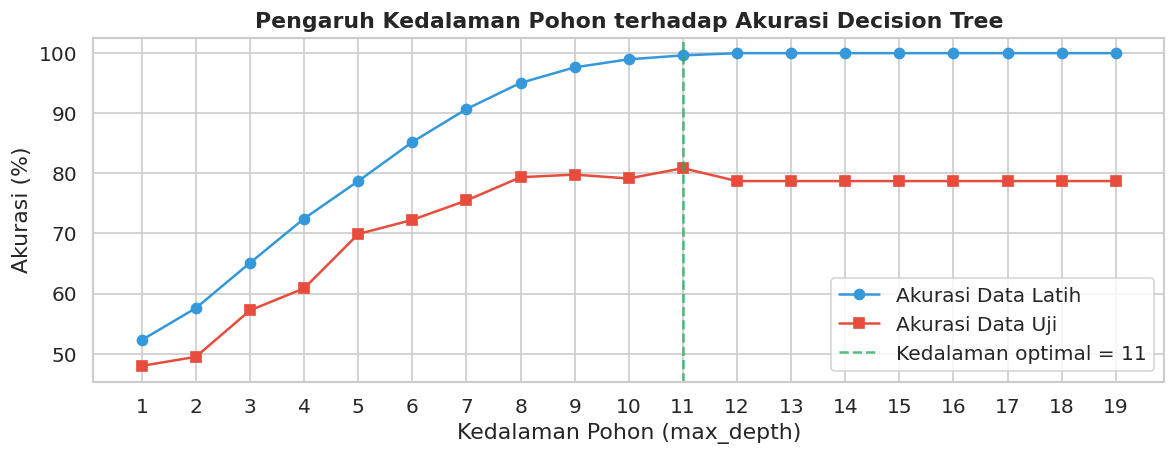

✅ Kedalaman optimal : 11
   Akurasi data uji : 80.86%


In [ ]:
# ── Cari kedalaman pohon optimal ─────────────────────────────
depths = range(1, 20)
train_scores_dt, test_scores_dt = [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_scores_dt.append(dt.score(X_train, y_train))
    test_scores_dt.append(dt.score(X_test, y_test))

best_depth = depths[test_scores_dt.index(max(test_scores_dt))]

plt.figure(figsize=(10, 4))
plt.plot(depths, [s*100 for s in train_scores_dt], 'o-',
         color='#3498DB', label='Akurasi Data Latih')
plt.plot(depths, [s*100 for s in test_scores_dt], 's-',
         color='#E74C3C', label='Akurasi Data Uji')
plt.axvline(x=best_depth, color='#27AE60', linestyle='--', alpha=0.8,
            label=f'Kedalaman optimal = {best_depth}')
plt.xlabel('Kedalaman Pohon (max_depth)')
plt.ylabel('Akurasi (%)')
plt.title('Pengaruh Kedalaman Pohon terhadap Akurasi Decision Tree',
          fontweight='bold')
plt.legend()
plt.xticks(depths)
plt.tight_layout()
plt.savefig('DT_01_depth_vs_accuracy.png', bbox_inches='tight')
plt.show()

print(f'✅ Kedalaman optimal : {best_depth}')
print(f'   Akurasi data uji : {max(test_scores_dt)*100:.2f}%')

In [ ]:
# ── Hyperparameter Tuning GridSearchCV ───────────────────────
param_dt = {
    'max_depth'        : [best_depth-1, best_depth, best_depth+1, best_depth+2],
    'criterion'        : ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}
param_dt['max_depth'] = [d for d in param_dt['max_depth'] if d and d > 0]

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_dt, cv=5, scoring='accuracy', n_jobs=-1
)
grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_

print('✅ Hyperparameter tuning selesai!')
print('   Parameter terbaik Decision Tree:')
for k, v in grid_dt.best_params_.items():
    print(f'   {k:25s}: {v}')
print(f'\n   CV Accuracy terbaik: {grid_dt.best_score_*100:.2f}%')

✅ Hyperparameter tuning selesai!
   Parameter terbaik Decision Tree:
   criterion                : gini
   max_depth                : 13
   min_samples_leaf         : 1
   min_samples_split        : 2

   CV Accuracy terbaik: 81.77%


In [ ]:
# ── Evaluasi Decision Tree ────────────────────────────────────
y_pred_dt = best_dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

print('=' * 55)
print('📊 EVALUASI — DECISION TREE')
print('=' * 55)
print(f'Accuracy: {acc_dt*100:.2f}%')
print()
print(classification_report(y_test, y_pred_dt, target_names=LABEL_NAMES))

📊 EVALUASI — DECISION TREE
Accuracy: 78.71%

              precision    recall  f1-score   support

      Rendah       0.86      0.77      0.82       154
      Sedang       0.65      0.77      0.70       153
      Tinggi       0.89      0.82      0.85       158

    accuracy                           0.79       465
   macro avg       0.80      0.79      0.79       465
weighted avg       0.80      0.79      0.79       465



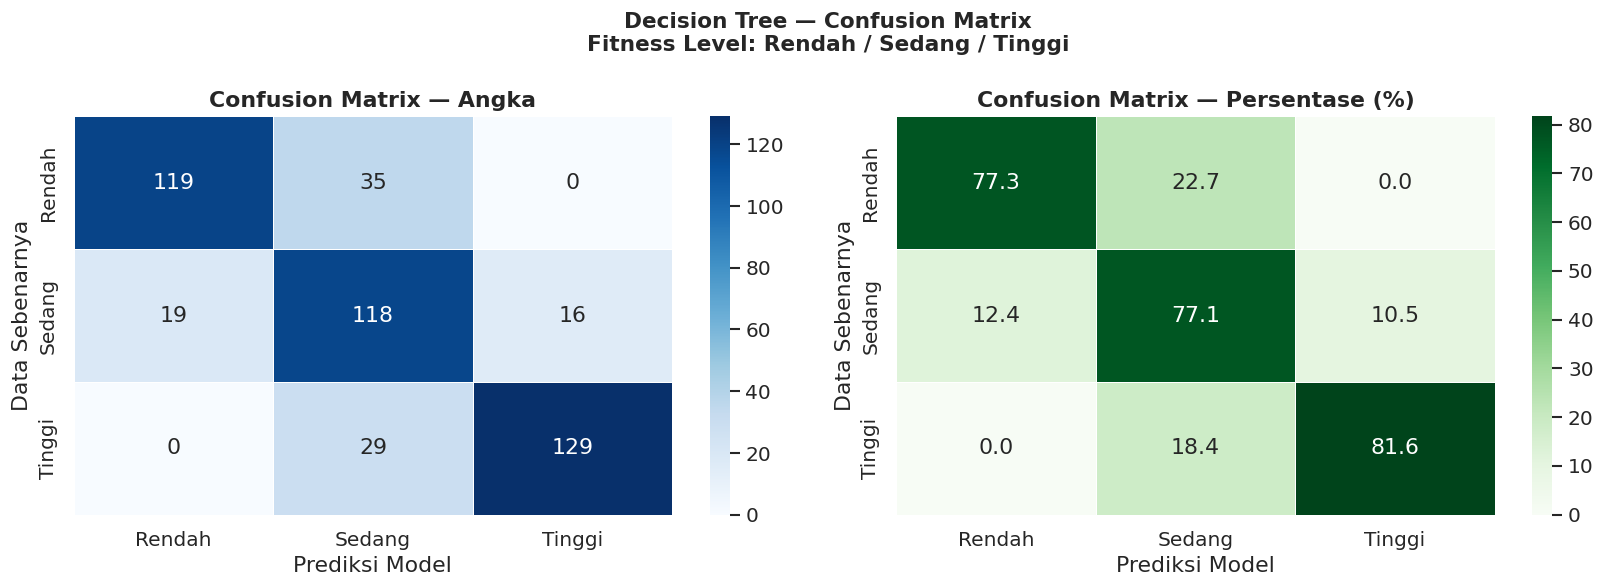

In [ ]:
# ── Confusion Matrix Decision Tree ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_dt = confusion_matrix(y_test, y_pred_dt, labels=LABEL_NAMES)

# Confusion matrix angka
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            linewidths=0.5)
axes[0].set_title('Confusion Matrix — Angka', fontweight='bold')
axes[0].set_xlabel('Prediksi Model')
axes[0].set_ylabel('Data Sebenarnya')

# Confusion matrix persentase
cm_pct = cm_dt.astype('float') / cm_dt.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Greens', ax=axes[1],
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            linewidths=0.5)
axes[1].set_title('Confusion Matrix — Persentase (%)', fontweight='bold')
axes[1].set_xlabel('Prediksi Model')
axes[1].set_ylabel('Data Sebenarnya')

plt.suptitle(f'Decision Tree — Confusion Matrix\nFitness Level: Rendah / Sedang / Tinggi',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('DT_02_confusion_matrix.png', bbox_inches='tight')
plt.show()

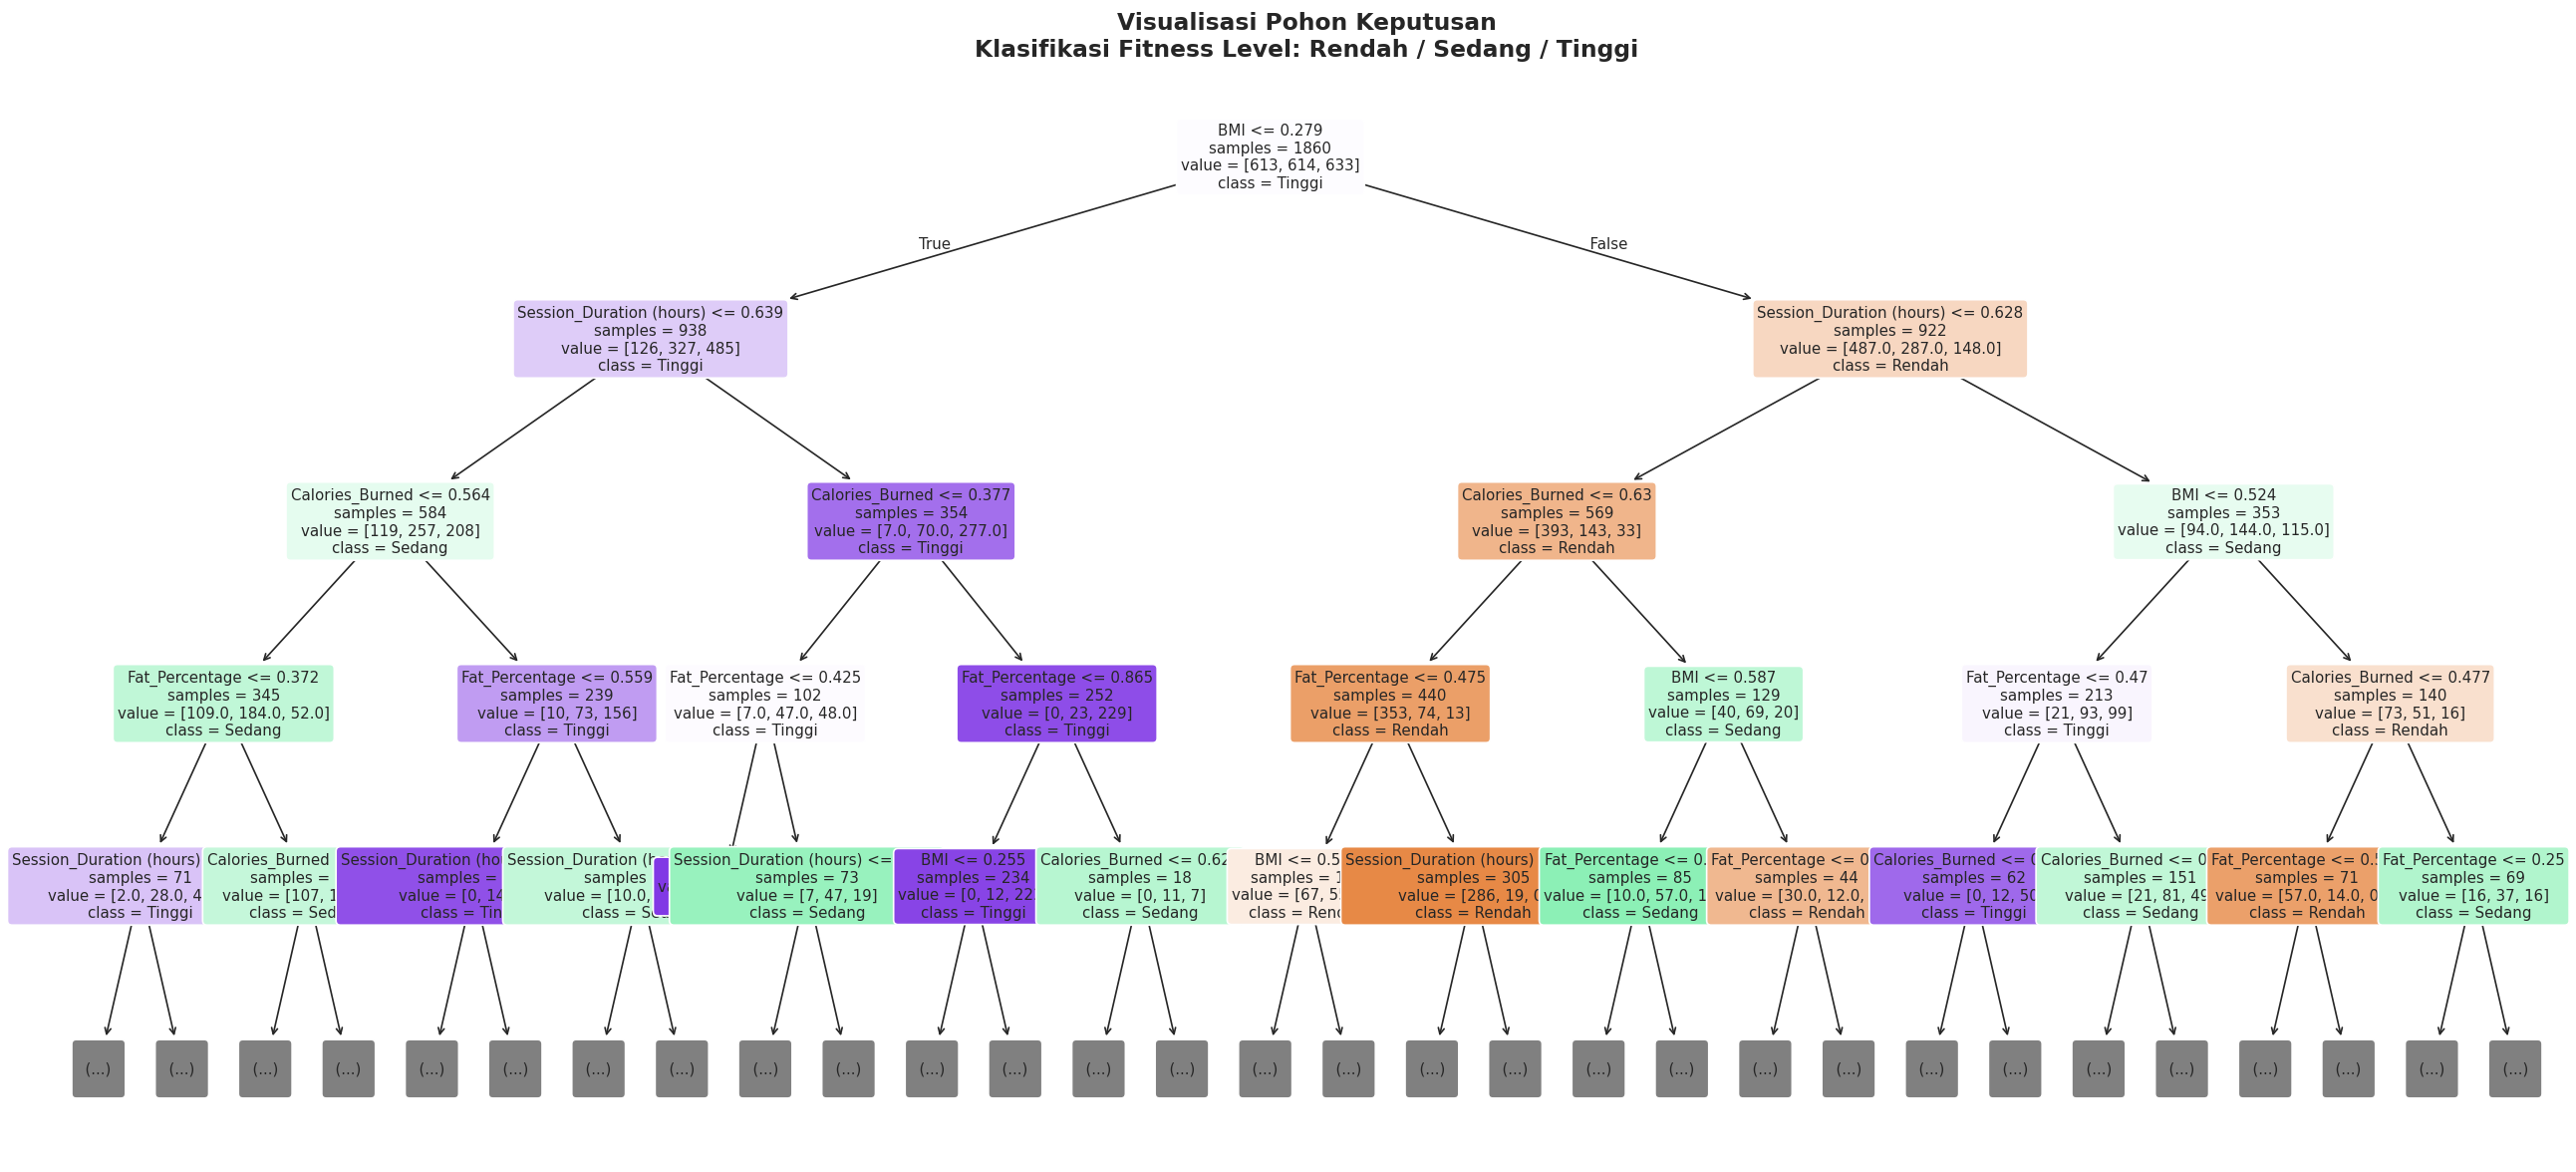

✅ Pohon keputusan tersimpan: DT_03_pohon_keputusan.png

📋 Contoh Aturan Keputusan (Decision Rules):
|--- BMI <= 0.28
|   |--- Session_Duration (hours) <= 0.64
|   |   |--- Calories_Burned <= 0.56
|   |   |   |--- Fat_Percentage <= 0.37
|   |   |   |   |--- Session_Duration (hours) <= 0.41
|   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |   |--- Session_Duration (hours) >  0.41
|   |   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- Fat_Percentage >  0.37
|   |   |   |   |--- Calories_Burned <= 0.39
|   |   |   |   |   |--- truncated branch of depth 8
|   |   |   |   |--- Calories_Burned >  0.39
|   |   |   |   |   |--- truncated branch of depth 8
|   |   |--- Calories_Burned >  0.56
|   |   |   |--- Fat_Percentage <= 0.56
|   |   |   |   |--- Session_Duration (hours) <= 0.26
|   |   |   |   |   |--- truncated branch of depth 4
|   |   |   |   |--- Session_Duration (hours) >  0.26
|   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- Fat_Pe

In [ ]:
# ── Visualisasi Pohon Keputusan ───────────────────────────────
plt.figure(figsize=(22, 10))
plot_tree(
    best_dt,
    feature_names=selected,
    class_names=LABEL_NAMES,
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=9,
    impurity=False
)
plt.title('Visualisasi Pohon Keputusan\nKlasifikasi Fitness Level: Rendah / Sedang / Tinggi',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('DT_03_pohon_keputusan.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Pohon keputusan tersimpan: DT_03_pohon_keputusan.png')

# Aturan IF-THEN
print('\n📋 Contoh Aturan Keputusan (Decision Rules):')
print('=' * 55)
rules = export_text(best_dt, feature_names=selected, max_depth=4)
for line in rules.split('\n')[:40]:
    print(line)

In [ ]:
# ── Cross Validation Decision Tree ───────────────────────────
cv_dt = cross_val_score(best_dt, X_scaled, y, cv=5, scoring='accuracy')
print(f'Cross-Validation Decision Tree (5-Fold):')
print(f'  Scores : {[round(s*100, 2) for s in cv_dt]}%')
print(f'  Mean   : {cv_dt.mean()*100:.2f}%')
print(f'  Std    : {cv_dt.std()*100:.2f}%')

Cross-Validation Decision Tree (5-Fold):
  Scores : [np.float64(79.78), np.float64(84.09), np.float64(77.85), np.float64(81.94), np.float64(83.01)]%
  Mean   : 81.33%
  Std    : 2.25%


KNN

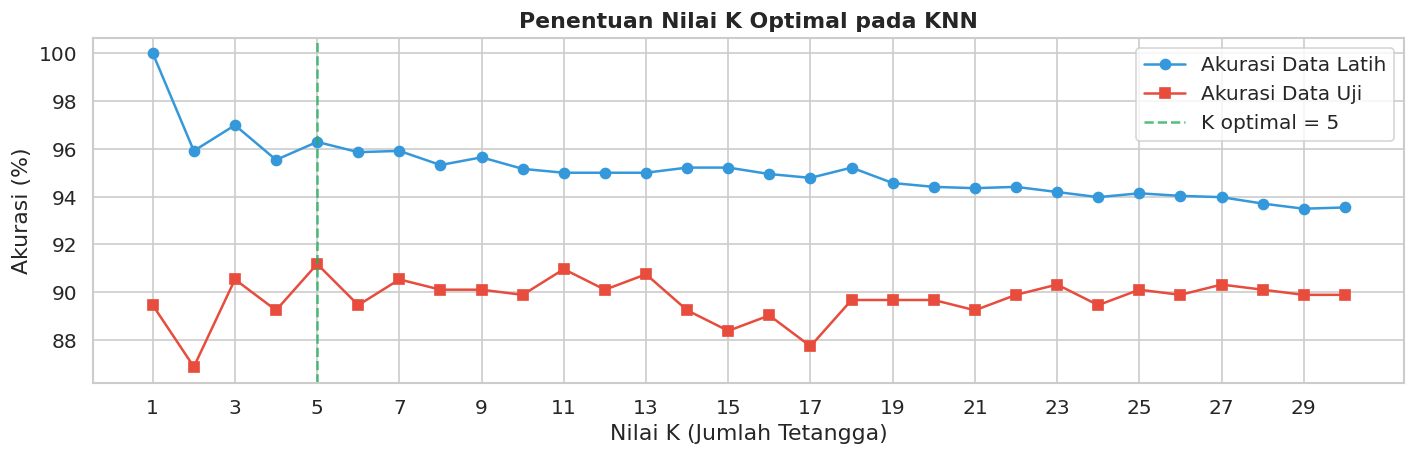

✅ Nilai K optimal: 5
   Akurasi data uji: 91.18%


In [ ]:
# ── Cari nilai K optimal ──────────────────────────────────────
k_values = range(1, 31)
train_acc_knn, test_acc_knn = [], []

for k in k_values:
    knn_tmp = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_tmp.fit(X_train, y_train)
    train_acc_knn.append(knn_tmp.score(X_train, y_train))
    test_acc_knn.append(knn_tmp.score(X_test, y_test))

best_k = k_values[np.argmax(test_acc_knn)]

plt.figure(figsize=(12, 4))
plt.plot(k_values, [s*100 for s in train_acc_knn], 'o-',
         color='#3498DB', label='Akurasi Data Latih')
plt.plot(k_values, [s*100 for s in test_acc_knn], 's-',
         color='#E74C3C', label='Akurasi Data Uji')
plt.axvline(best_k, color='#27AE60', linestyle='--', alpha=0.8,
            label=f'K optimal = {best_k}')
plt.xlabel('Nilai K (Jumlah Tetangga)')
plt.ylabel('Akurasi (%)')
plt.title('Penentuan Nilai K Optimal pada KNN', fontweight='bold')
plt.legend()
plt.xticks(range(1, 31, 2))
plt.tight_layout()
plt.savefig('KNN_01_k_vs_accuracy.png', bbox_inches='tight')
plt.show()

print(f'✅ Nilai K optimal: {best_k}')
print(f'   Akurasi data uji: {max(test_acc_knn)*100:.2f}%')

In [ ]:
# ── Hyperparameter Tuning KNN ─────────────────────────────────
param_knn = {
    'n_neighbors': list(range(max(1, best_k-5), best_k+6)),
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan']
}
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_knn, cv=5, scoring='accuracy', n_jobs=-1
)
grid_knn.fit(X_train, y_train)
best_knn = grid_knn.best_estimator_

print('✅ Hyperparameter tuning KNN selesai!')
print('   Parameter terbaik KNN:')
for k, v in grid_knn.best_params_.items():
    print(f'   {k:15s}: {v}')
print(f'\n   CV Accuracy terbaik: {grid_knn.best_score_*100:.2f}%')

✅ Hyperparameter tuning KNN selesai!
   Parameter terbaik KNN:
   metric         : euclidean
   n_neighbors    : 10
   weights        : distance

   CV Accuracy terbaik: 93.28%


In [ ]:
# ── Evaluasi KNN ─────────────────────────────────────────────
y_pred_knn = best_knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)

print('=' * 55)
print('📊 EVALUASI — KNN')
print('=' * 55)
print(f'Accuracy: {acc_knn*100:.2f}%')
print()
print(classification_report(y_test, y_pred_knn, target_names=LABEL_NAMES))

📊 EVALUASI — KNN
Accuracy: 91.18%

              precision    recall  f1-score   support

      Rendah       0.93      0.91      0.92       154
      Sedang       0.84      0.90      0.87       153
      Tinggi       0.97      0.92      0.94       158

    accuracy                           0.91       465
   macro avg       0.91      0.91      0.91       465
weighted avg       0.91      0.91      0.91       465



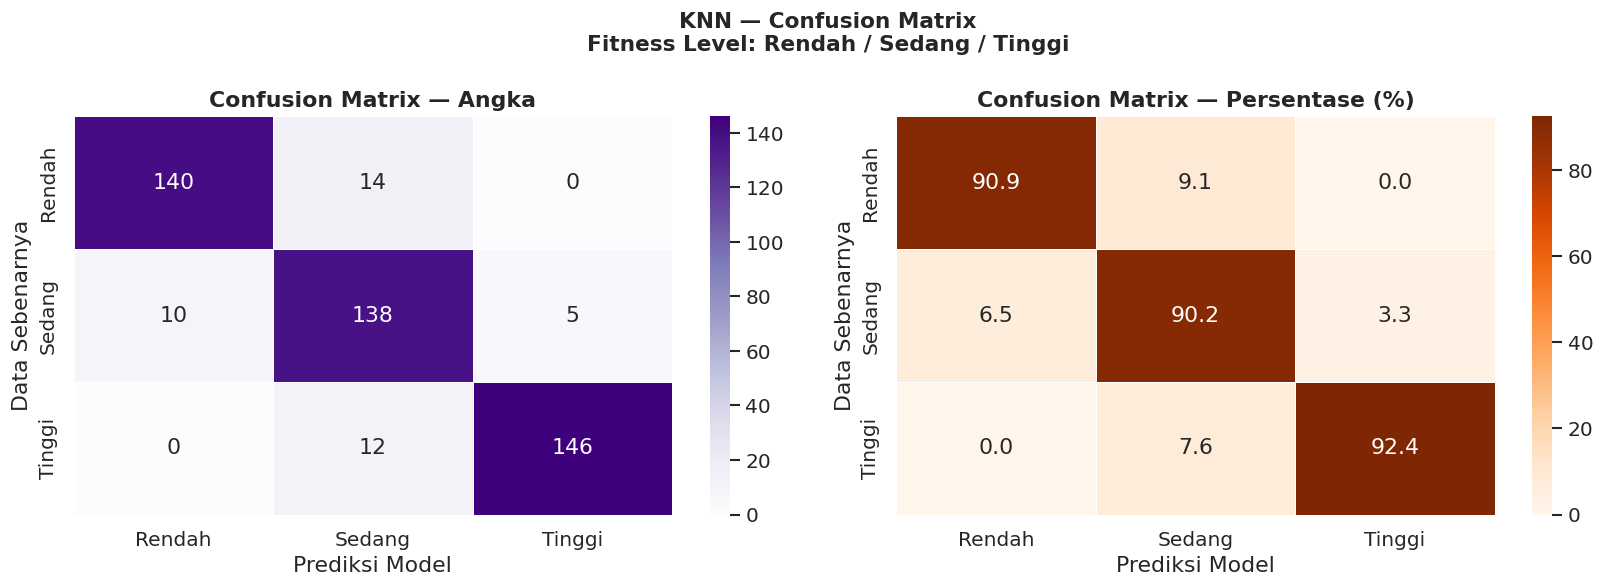

In [ ]:
# ── Confusion Matrix KNN ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_knn = confusion_matrix(y_test, y_pred_knn, labels=LABEL_NAMES)

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, linewidths=0.5)
axes[0].set_title('Confusion Matrix — Angka', fontweight='bold')
axes[0].set_xlabel('Prediksi Model')
axes[0].set_ylabel('Data Sebenarnya')

cm_knn_pct = cm_knn.astype('float') / cm_knn.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_knn_pct, annot=True, fmt='.1f', cmap='Oranges', ax=axes[1],
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, linewidths=0.5)
axes[1].set_title('Confusion Matrix — Persentase (%)', fontweight='bold')
axes[1].set_xlabel('Prediksi Model')
axes[1].set_ylabel('Data Sebenarnya')

plt.suptitle(f'KNN — Confusion Matrix\nFitness Level: Rendah / Sedang / Tinggi',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('KNN_02_confusion_matrix.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Cross Validation KNN ──────────────────────────────────────
cv_knn = cross_val_score(best_knn, X_scaled, y, cv=5, scoring='accuracy')
print(f'Cross-Validation KNN (5-Fold):')
print(f'  Scores : {[round(s*100, 2) for s in cv_knn]}%')
print(f'  Mean   : {cv_knn.mean()*100:.2f}%')
print(f'  Std    : {cv_knn.std()*100:.2f}%')

Cross-Validation KNN (5-Fold):
  Scores : [np.float64(92.9), np.float64(93.76), np.float64(92.26), np.float64(91.61), np.float64(95.27)]%
  Mean   : 93.16%
  Std    : 1.27%


Perbandingan

In [ ]:
# ── Tabel Perbandingan ────────────────────────────────────────
hasil = pd.DataFrame([
    {
        'Model'        : f'Decision Tree',
        'Parameter'    : f'depth={grid_dt.best_params_["max_depth"]}, criterion={grid_dt.best_params_["criterion"]}',
        'Accuracy (%)'  : round(accuracy_score(y_test, y_pred_dt) * 100, 2),
        'Precision (%)'  : round(precision_score(y_test, y_pred_dt, average='weighted') * 100, 2),
        'Recall (%)'    : round(recall_score(y_test, y_pred_dt, average='weighted') * 100, 2),
        'F1-Score (%)'  : round(f1_score(y_test, y_pred_dt, average='weighted') * 100, 2),
        'CV Mean (%)'   : round(cv_dt.mean() * 100, 2),
        'CV Std (%)'    : round(cv_dt.std() * 100, 2),
    },
    {
        'Model'        : f'KNN',
        'Parameter'    : f'K={grid_knn.best_params_["n_neighbors"]}, metric={grid_knn.best_params_["metric"]}',
        'Accuracy (%)'  : round(accuracy_score(y_test, y_pred_knn) * 100, 2),
        'Precision (%)'  : round(precision_score(y_test, y_pred_knn, average='weighted') * 100, 2),
        'Recall (%)'    : round(recall_score(y_test, y_pred_knn, average='weighted') * 100, 2),
        'F1-Score (%)'  : round(f1_score(y_test, y_pred_knn, average='weighted') * 100, 2),
        'CV Mean (%)'   : round(cv_knn.mean() * 100, 2),
        'CV Std (%)'    : round(cv_knn.std() * 100, 2),
    }
])

print('📋 TABEL PERBANDINGAN MODEL')
print('=' * 70)
display(hasil.set_index('Model'))

best_row  = hasil.loc[hasil['F1-Score (%)'].idxmax()]
print(f'\n🏆 Model Terbaik : {best_row["Model"]}')
print(f'   F1-Score      : {best_row["F1-Score (%)"]:.2f}%')
print(f'   Accuracy      : {best_row["Accuracy (%)"]:.2f}%')

📋 TABEL PERBANDINGAN MODEL


,Parameter,Accuracy (%),Precision (%),Recall (%),F1-Score (%),CV Mean (%),CV Std (%)
Model,,,,,,,
Decision Tree,"depth=13, criterion=gini",78.71,80.12,78.71,79.11,81.33,2.25
KNN,"K=10, metric=euclidean",91.18,91.45,91.18,91.26,93.16,1.27



🏆 Model Terbaik : KNN
   F1-Score      : 91.26%
   Accuracy      : 91.18%


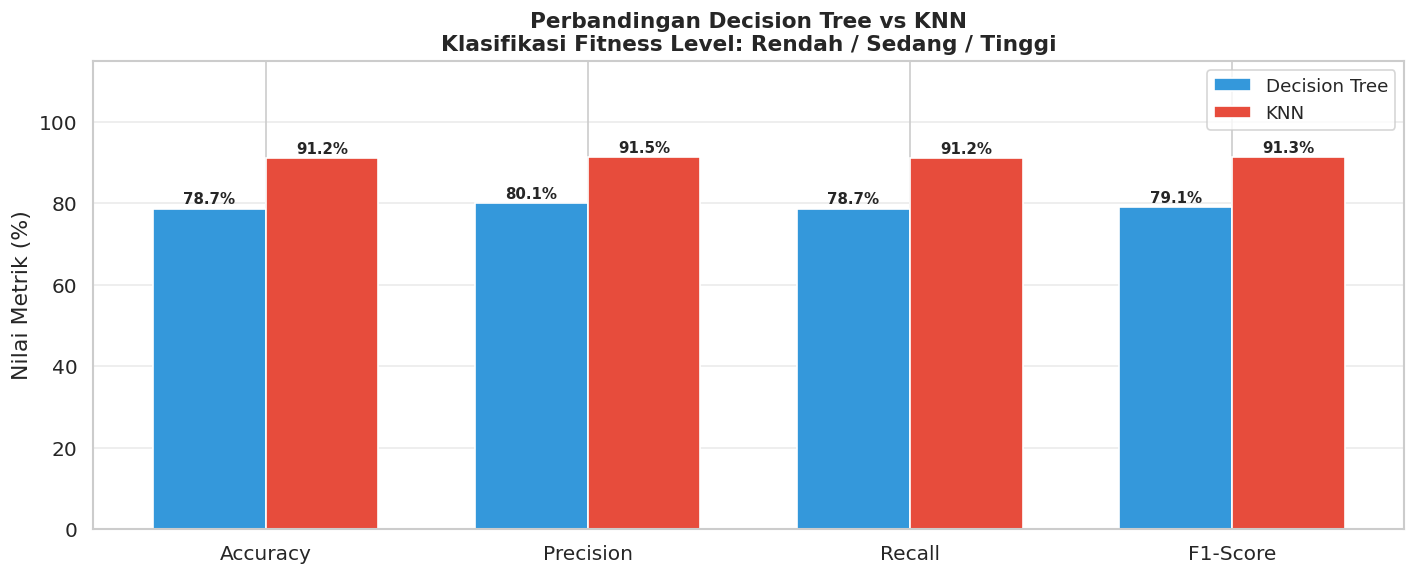

In [ ]:
# ── Bar Chart Perbandingan ────────────────────────────────────
metrik_list = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
x = np.arange(len(metrik_list))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - w/2, hasil.iloc[0][metrik_list], w,
            label='Decision Tree', color='#3498DB', edgecolor='white')
b2 = ax.bar(x + w/2, hasil.iloc[1][metrik_list], w,
            label='KNN', color='#E74C3C', edgecolor='white')

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Nilai Metrik (%)')
ax.set_title(
    'Perbandingan Decision Tree vs KNN\nKlasifikasi Fitness Level: Rendah / Sedang / Tinggi',
    fontsize=13, fontweight='bold'
)
ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1-Score'])
ax.set_ylim(0, 115)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('COMPARE_01_bar_chart.png', bbox_inches='tight')
plt.show()

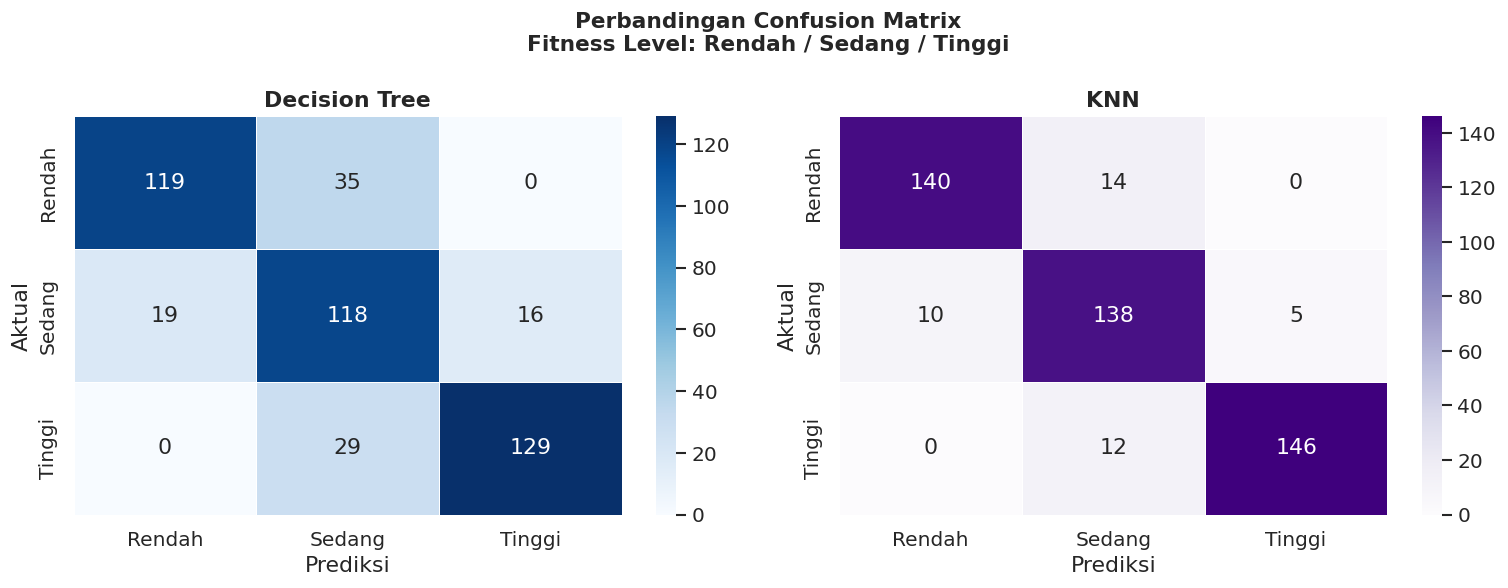

In [ ]:
# ── Confusion Matrix Berdampingan ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, cm, title, cmap in zip(
    axes,
    [cm_dt, cm_knn],
    ['Decision Tree', 'KNN'],
    ['Blues', 'Purples']
):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
                linewidths=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.suptitle('Perbandingan Confusion Matrix\nFitness Level: Rendah / Sedang / Tinggi',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('COMPARE_02_confusion_matrix.png', bbox_inches='tight')
plt.show()

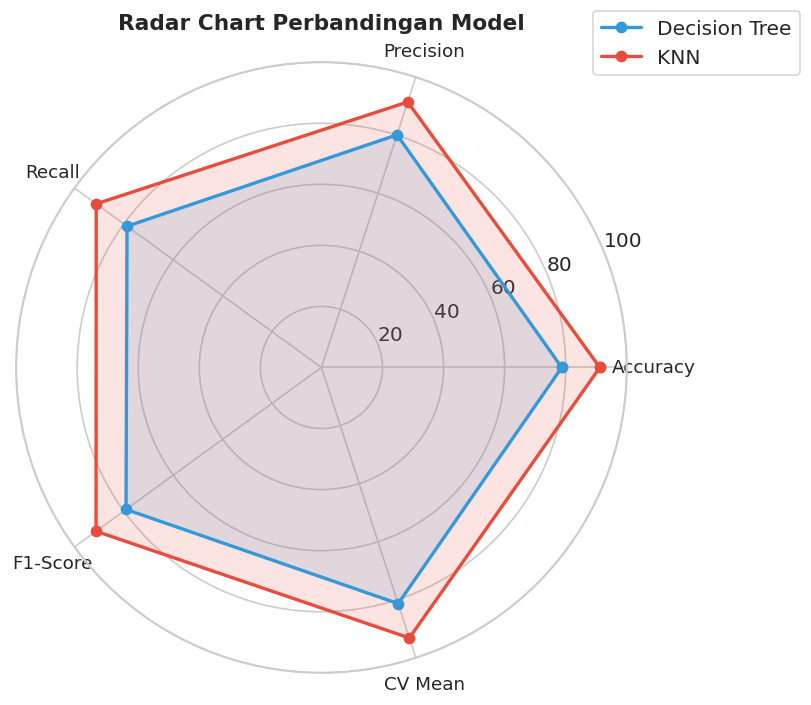

In [ ]:
# ── Radar Chart ───────────────────────────────────────────────
categories = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)', 'CV Mean (%)']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for i, (model, color) in enumerate(zip(['Decision Tree', 'KNN'], ['#3498DB', '#E74C3C'])):
    vals = hasil[hasil['Model'] == model][categories].values.flatten().tolist()
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, color=color, label=model)
    ax.fill(angles, vals, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1-Score', 'CV Mean'], fontsize=11)
ax.set_ylim(0, 100)
ax.set_title('Radar Chart Perbandingan Model', fontsize=13,
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('COMPARE_03_radar_chart.png', bbox_inches='tight')
plt.show()

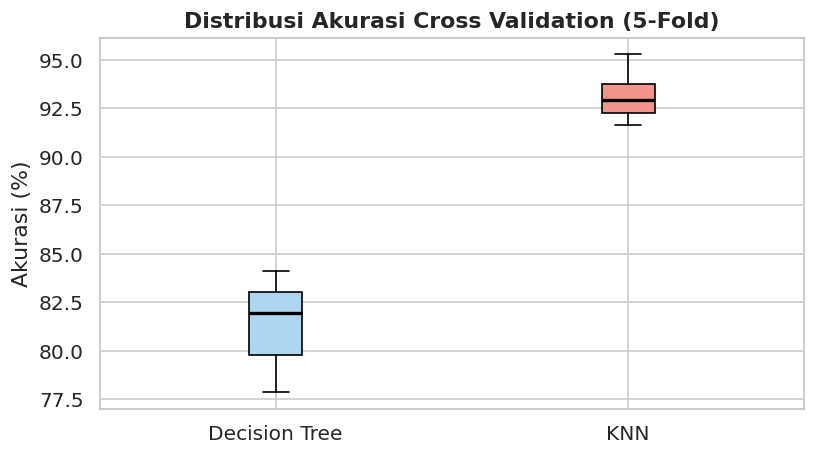

Decision Tree CV: 81.33% ± 2.25%
KNN           CV: 93.16% ± 1.27%


In [ ]:
# ── Boxplot Cross Validation ──────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
bp = ax.boxplot(
    [cv_dt * 100, cv_knn * 100],
    labels=['Decision Tree', 'KNN'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
bp['boxes'][0].set_facecolor('#AED6F1')
bp['boxes'][1].set_facecolor('#F1948A')
ax.set_ylabel('Akurasi (%)')
ax.set_title('Distribusi Akurasi Cross Validation (5-Fold)', fontweight='bold')
plt.tight_layout()
plt.savefig('COMPARE_04_cross_validation.png', bbox_inches='tight')
plt.show()

print(f'Decision Tree CV: {cv_dt.mean()*100:.2f}% ± {cv_dt.std()*100:.2f}%')
print(f'KNN           CV: {cv_knn.mean()*100:.2f}% ± {cv_knn.std()*100:.2f}%')

In [ ]:
# ── Ringkasan Lengkap ─────────────────────────────────────────
print('=' * 65)
print('  RINGKASAN HASIL PENELITIAN')
print('  Klasifikasi Pola Aktivitas Fisik terhadap Kebugaran')
print('=' * 65)

print(f'\n📦 Dataset        : Kaggle Fitness Tracker ({len(df)} sampel)')
print(f'🎯 Target         : Fitness Level (Rendah / Sedang / Tinggi)')
print(f'🔢 Fitur digunakan: {len(selected)} fitur → {selected}')
print(f'✂️  Split data     : 80% latih ({len(X_train)}) / 20% uji ({len(X_test)})')

print(f'\n📊 Cara penentuan label Fitness Level:')
print(f'   Fitness Score ≤ {p33:.4f}             → Rendah')
print(f'   Fitness Score {p33:.4f} – {p66:.4f}   → Sedang')
print(f'   Fitness Score > {p66:.4f}             → Tinggi')

for _, r in hasil.iterrows():
    print(f'\n── {r["Model"]} ({r["Parameter"]}) ─────────────')
    print(f'   Accuracy   : {r["Accuracy (%)"]:.2f}%')
    print(f'   Precision  : {r["Precision (%)"]:.2f}%')
    print(f'   Recall     : {r["Recall (%)"]:.2f}%')
    print(f'   F1-Score   : {r["F1-Score (%)"]:.2f}%')
    print(f'   CV 5-fold  : {r["CV Mean (%)"]:.2f}% ± {r["CV Std (%)"]:.2f}%')

print(f'\n🏆 Model Terbaik  : {best_row["Model"]}')
print(f'   F1-Score      : {best_row["F1-Score (%)"]:.2f}%')

imp_top = imp_df.sort_values('Importance', ascending=False).head(3)
print(f'\n📌 3 Fitur Paling Berpengaruh terhadap Fitness Level:')
for i, (_, r) in enumerate(imp_top.iterrows(), 1):
    print(f'   {i}. {r["Fitur"]:35s}: {r["Importance"]:.4f}')

print('\n' + '=' * 65)
print('  ✅ Selesai!')
print('=' * 65)

  RINGKASAN HASIL PENELITIAN
  Klasifikasi Pola Aktivitas Fisik terhadap Kebugaran

📦 Dataset        : Kaggle Fitness Tracker (2325 sampel)
🎯 Target         : Fitness Level (Rendah / Sedang / Tinggi)
🔢 Fitur digunakan: 4 fitur → ['Session_Duration (hours)', 'Fat_Percentage', 'BMI', 'Calories_Burned']
✂️  Split data     : 80% latih (1860) / 20% uji (465)

📊 Cara penentuan label Fitness Level:
   Fitness Score ≤ 0.5005             → Rendah
   Fitness Score 0.5005 – 0.6046   → Sedang
   Fitness Score > 0.6046             → Tinggi

── Decision Tree (depth=13, criterion=gini) ─────────────
   Accuracy   : 78.71%
   Precision  : 80.12%
   Recall     : 78.71%
   F1-Score   : 79.11%
   CV 5-fold  : 81.33% ± 2.25%

── KNN (K=10, metric=euclidean) ─────────────
   Accuracy   : 91.18%
   Precision  : 91.45%
   Recall     : 91.18%
   F1-Score   : 91.26%
   CV 5-fold  : 93.16% ± 1.27%

🏆 Model Terbaik  : KNN
   F1-Score      : 91.26%

📌 3 Fitur Paling Berpengaruh terhadap Fitness Level:
   1. Calor

In [ ]:
# ── Contoh Prediksi Data Baru ─────────────────────────────────
# Isi nilai sesuai urutan fitur di 'selected'
print(f'Urutan fitur yang diperlukan: {selected}\n')

# ══ CONTOH: Orang yang kemungkinan TINGGI ══
data_contoh = {
    'Session_Duration (hours)':      1.8,
    'Calories_Burned':               900,
    'Workout_Frequency (days/week)': 5,
    'Water_Intake (liters)':         3.0,
    'Resting_BPM':                   52,
    'Fat_Percentage':                15,
    'BMI':                           22,
    'Avg_BPM':                       140,
    'Max_BPM':                       175,
    'Age':                           28,
    'Gender':                        1,
    'Weight (kg)':                   70,
    'Height (m)':                    1.75,
    'Workout_Type':                  2
}

# Buat DataFrame hanya dengan fitur-fitur yang terpilih ('selected')
# dan pastikan urutannya sesuai dengan yang digunakan saat fitting scaler
sample_df = pd.DataFrame([{col: data_contoh.get(col, 0) for col in selected}])
sample_scaled = scaler.transform(sample_df.values[:, :])

pred_dt  = best_dt.predict(sample_scaled)[0]
pred_knn = best_knn.predict(sample_scaled)[0]
prob_dt  = best_dt.predict_proba(sample_scaled)[0]
prob_knn = best_knn.predict_proba(sample_scaled)[0]
classes  = best_dt.classes_

print('=' * 55)
print('  HASIL PREDIKSI DATA BARU')
print('=' * 55)
print(f'Decision Tree → Fitness Level: {pred_dt}')
for cls, p in zip(classes, prob_dt):
    print(f'   Probabilitas {cls:10s}: {p*100:.1f}%')

print(f'\nKNN           → Fitness Level: {pred_knn}')
for cls, p in zip(classes, prob_knn):
    print(f'   Probabilitas {cls:10s}: {p*100:.1f}%')

Urutan fitur yang diperlukan: ['Session_Duration (hours)', 'Fat_Percentage', 'BMI', 'Calories_Burned']

  HASIL PREDIKSI DATA BARU
Decision Tree → Fitness Level: Rendah
   Probabilitas Rendah    : 100.0%
   Probabilitas Sedang    : 0.0%
   Probabilitas Tinggi    : 0.0%

KNN           → Fitness Level: Sedang
   Probabilitas Rendah    : 20.0%
   Probabilitas Sedang    : 60.0%
   Probabilitas Tinggi    : 20.0%


RANDOM FOREST

In [ ]:
# ════════════════════════════════════════════════════════════
#   MODEL — RANDOM FOREST CLASSIFIER
#   Klasifikasi Pola Aktivitas Fisik terhadap Tingkat Kebugaran
# ════════════════════════════════════════════════════════════
from sklearn.ensemble import RandomForestClassifier

print('=' * 60)
print('  RANDOM FOREST — PERSIAPAN DATA')
print('=' * 60)

# ── Pisahkan fitur (X) dan target (y) ───────────────────────
# Gunakan fitur numerik yang tersedia di dataset
exclude_cols = ['Fitness_Level', 'Fitness_Score', 'Experience_Level']
feature_cols = [c for c in df.select_dtypes(include='number').columns
                if c not in exclude_cols]

X = df[feature_cols].copy()
y = df['Fitness_Level']

print(f'\n📌 Fitur yang digunakan ({len(feature_cols)}):')
for f in feature_cols:
    print(f'   - {f}')
print(f'\n🎯 Target: {y.unique().tolist()}')
print(f'\nDistribusi kelas:')
for label in LABEL_NAMES:
    n   = (y == label).sum()
    bar = '█' * int(n / len(y) * 35)
    print(f'   {label:10s}: {n:4d} data  {bar}')

  RANDOM FOREST — PERSIAPAN DATA

📌 Fitur yang digunakan (8):
   - Calories_Burned
   - Fat_Percentage
   - BMI
   - Weight (kg)
   - Height (m)
   - Session_Duration (hours)
   - Age
   - Avg_BPM

🎯 Target: ['Tinggi', 'Rendah', 'Sedang']

Distribusi kelas:
   Rendah    :  767 data  ███████████
   Sedang    :  767 data  ███████████
   Tinggi    :  791 data  ███████████


In [ ]:
# ── Normalisasi & Split 80/20 ────────────────────────────────
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

scaler_rf = MinMaxScaler()
X_scaled  = pd.DataFrame(scaler_rf.fit_transform(X), columns=X.columns)

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'✅ Normalisasi & split selesai!')
print(f'   Data latih : {len(X_train_rf)} data (80%)')
print(f'   Data uji   : {len(X_test_rf)} data (20%)')
print(f'\n   Distribusi data latih:')
for label in LABEL_NAMES:
    print(f'     {label}: {(y_train_rf == label).sum()} data')

✅ Normalisasi & split selesai!
   Data latih : 1860 data (80%)
   Data uji   : 465 data (20%)

   Distribusi data latih:
     Rendah: 613 data
     Sedang: 614 data
     Tinggi: 633 data


Mencari n_estimators optimal...
   n_trees= 10 | Train=99.95% | Test=79.35%
   n_trees= 25 | Train=100.00% | Test=83.23%
   n_trees= 50 | Train=100.00% | Test=84.52%
   n_trees= 75 | Train=100.00% | Test=84.30%
   n_trees=100 | Train=100.00% | Test=84.73%
   n_trees=150 | Train=100.00% | Test=84.73%
   n_trees=200 | Train=100.00% | Test=85.59%


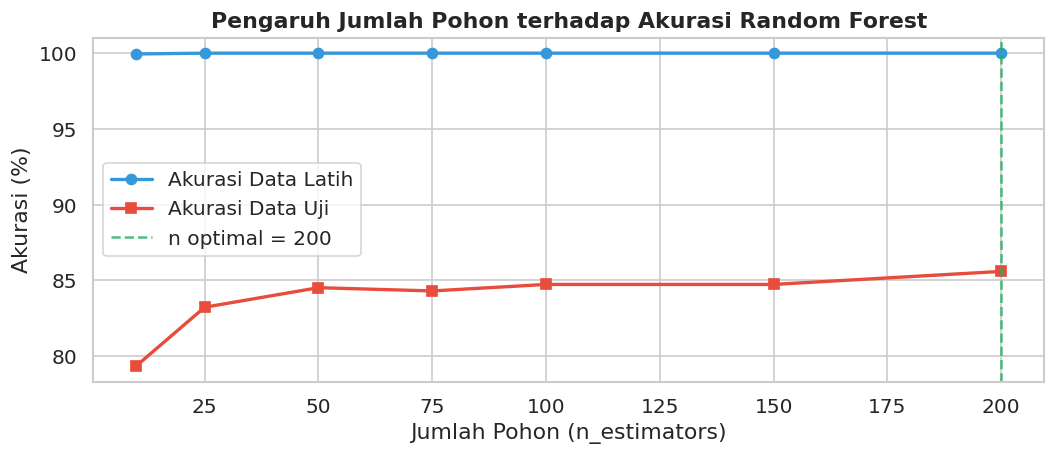


✅ Jumlah pohon optimal: 200


In [ ]:
# ── Cari jumlah pohon (n_estimators) optimal ─────────────────
# Penjelasan: Random Forest membuat banyak Decision Tree
# Makin banyak pohon → makin stabil, tapi makin lama
# Kita cari jumlah pohon yang memberikan akurasi tertinggi

n_trees_list  = [10, 25, 50, 75, 100, 150, 200]
acc_train_rf  = []
acc_test_rf   = []

print('Mencari n_estimators optimal...')
for n in n_trees_list:
    rf_tmp = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf_tmp.fit(X_train_rf, y_train_rf)
    acc_train_rf.append(rf_tmp.score(X_train_rf, y_train_rf))
    acc_test_rf.append(rf_tmp.score(X_test_rf, y_test_rf))
    print(f'   n_trees={n:3d} | Train={acc_train_rf[-1]*100:.2f}% | Test={acc_test_rf[-1]*100:.2f}%')

best_n = n_trees_list[np.argmax(acc_test_rf)]

# Visualisasi
plt.figure(figsize=(9, 4))
plt.plot(n_trees_list, [s*100 for s in acc_train_rf], 'o-',
         color='#3498DB', label='Akurasi Data Latih', linewidth=2)
plt.plot(n_trees_list, [s*100 for s in acc_test_rf],  's-',
         color='#E74C3C', label='Akurasi Data Uji', linewidth=2)
plt.axvline(x=best_n, color='#27AE60', linestyle='--',
            alpha=0.8, label=f'n optimal = {best_n}')
plt.xlabel('Jumlah Pohon (n_estimators)')
plt.ylabel('Akurasi (%)')
plt.title('Pengaruh Jumlah Pohon terhadap Akurasi Random Forest',
          fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('RF_01_n_estimators.png', bbox_inches='tight')
plt.show()
print(f'\n✅ Jumlah pohon optimal: {best_n}')

In [ ]:
# ── Hyperparameter Tuning (GridSearchCV) ─────────────────────
# GridSearchCV mencoba semua kombinasi parameter → pilih yang terbaik
# cv=5 artinya validasi silang 5-fold

param_grid = {
    'n_estimators'     : [best_n, best_n + 50],
    'max_depth'        : [None, 5, 10, 15],
    'max_features'     : ['sqrt', 'log2'],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2]
}

print('⏳ GridSearchCV sedang berjalan (mungkin 1-2 menit)...')
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
grid_rf.fit(X_train_rf, y_train_rf)
best_rf = grid_rf.best_estimator_

print('✅ Tuning selesai!')
print('\nParameter terbaik Random Forest:')
for k, v in grid_rf.best_params_.items():
    print(f'   {k:22s}: {v}')
print(f'\nCV Accuracy terbaik: {grid_rf.best_score_*100:.2f}%')

⏳ GridSearchCV sedang berjalan (mungkin 1-2 menit)...
✅ Tuning selesai!

Parameter terbaik Random Forest:
   max_depth             : None
   max_features          : log2
   min_samples_leaf      : 2
   min_samples_split     : 5
   n_estimators          : 200

CV Accuracy terbaik: 88.92%


In [ ]:
# ── Prediksi & Classification Report ─────────────────────────
y_pred_rf = best_rf.predict(X_test_rf)
acc_rf    = accuracy_score(y_test_rf, y_pred_rf)

print('=' * 60)
print('  EVALUASI RANDOM FOREST')
print('=' * 60)
print(f'\n  Accuracy : {acc_rf*100:.2f}%')
print()
print(classification_report(y_test_rf, y_pred_rf, target_names=LABEL_NAMES))

  EVALUASI RANDOM FOREST

  Accuracy : 85.59%

              precision    recall  f1-score   support

      Rendah       0.89      0.88      0.89       154
      Sedang       0.75      0.84      0.79       153
      Tinggi       0.95      0.84      0.89       158

    accuracy                           0.86       465
   macro avg       0.86      0.86      0.86       465
weighted avg       0.86      0.86      0.86       465



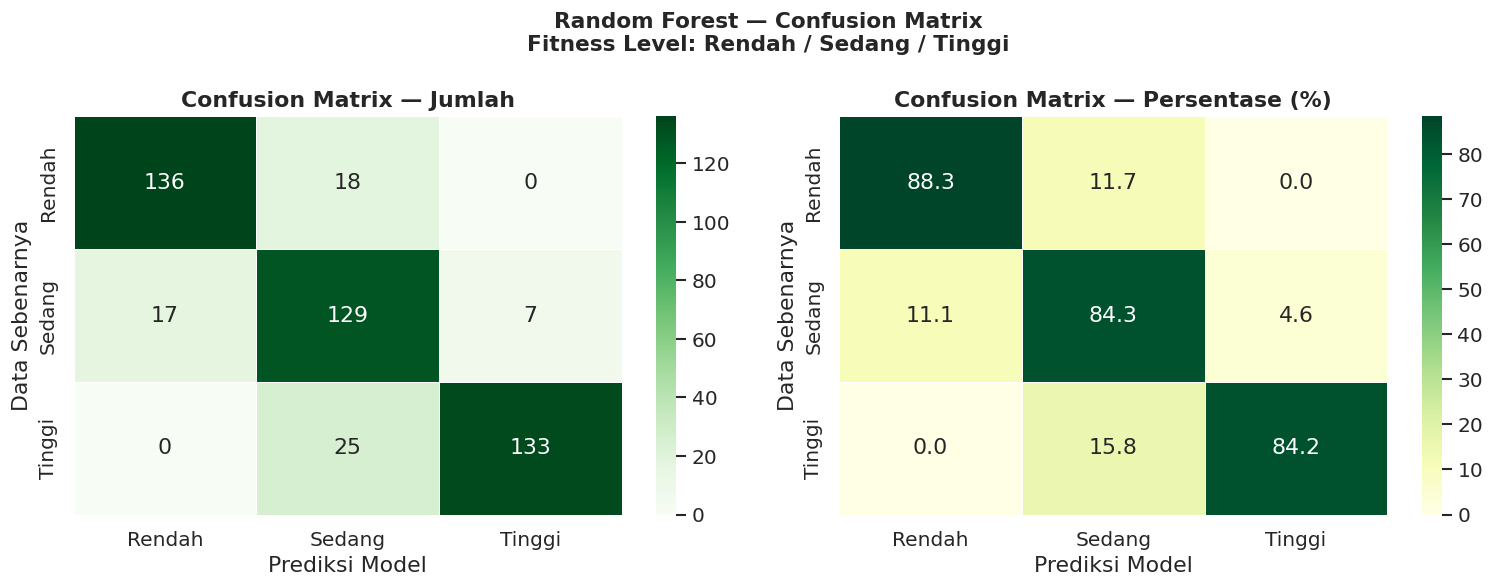

In [ ]:
# ── Confusion Matrix ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_rf  = confusion_matrix(y_test_rf, y_pred_rf, labels=LABEL_NAMES)

# Confusion matrix angka
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix — Jumlah', fontweight='bold')
axes[0].set_xlabel('Prediksi Model')
axes[0].set_ylabel('Data Sebenarnya')

# Confusion matrix persentase
cm_pct = cm_rf.astype(float) / cm_rf.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='YlGn',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix — Persentase (%)', fontweight='bold')
axes[1].set_xlabel('Prediksi Model')
axes[1].set_ylabel('Data Sebenarnya')

plt.suptitle('Random Forest — Confusion Matrix\nFitness Level: Rendah / Sedang / Tinggi',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('RF_02_confusion_matrix.png', bbox_inches='tight')
plt.show()

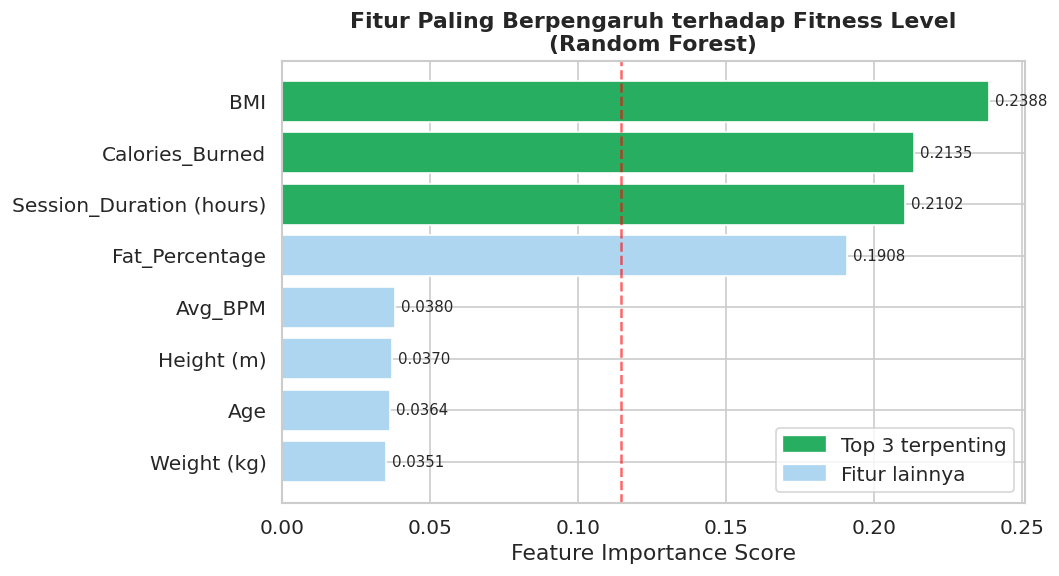


📌 Ranking Feature Importance:
   ⭐ 1. BMI                           : 0.2388
   ⭐ 2. Calories_Burned               : 0.2135
   ⭐ 3. Session_Duration (hours)      : 0.2102
      4. Fat_Percentage                : 0.1908
      5. Avg_BPM                       : 0.0380
      6. Height (m)                    : 0.0370
      7. Age                           : 0.0364
      8. Weight (kg)                   : 0.0351


In [ ]:
# ── Feature Importance ────────────────────────────────────────
# Menunjukkan fitur mana yang paling berpengaruh
# pada prediksi Fitness Level — jawab rumusan masalah skripsi!

imp_rf = pd.DataFrame({
    'Fitur'     : X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=True)

top3_rf = imp_rf.nlargest(3, 'Importance')['Fitur'].tolist()
bar_colors_rf = ['#27AE60' if f in top3_rf else '#AED6F1'
                 for f in imp_rf['Fitur']]

plt.figure(figsize=(9, 5))
bars = plt.barh(imp_rf['Fitur'], imp_rf['Importance'],
                color=bar_colors_rf, edgecolor='white')
for bar, val in zip(bars, imp_rf['Importance']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.axvline(imp_rf['Importance'].median(), color='red',
            linestyle='--', alpha=0.6, label='Median')
plt.xlabel('Feature Importance Score')
plt.title('Fitur Paling Berpengaruh terhadap Fitness Level\n(Random Forest)',
          fontweight='bold')
plt.legend(handles=[
    mpatches.Patch(color='#27AE60', label='Top 3 terpenting'),
    mpatches.Patch(color='#AED6F1', label='Fitur lainnya')
], loc='lower right')
plt.tight_layout()
plt.savefig('RF_03_feature_importance.png', bbox_inches='tight')
plt.show()

print('\n📌 Ranking Feature Importance:')
for i, (_, r) in enumerate(
    imp_rf.sort_values('Importance', ascending=False).iterrows(), 1
):
    mark = '⭐' if r['Fitur'] in top3_rf else '  '
    print(f'   {mark} {i}. {r["Fitur"]:30s}: {r["Importance"]:.4f}')

Cross Validation Random Forest (5-Fold):
  Scores : [np.float64(87.74), np.float64(89.46), np.float64(85.81), np.float64(88.39), np.float64(92.04)]%
  Mean   : 88.69%
  Std    : ± 2.06%


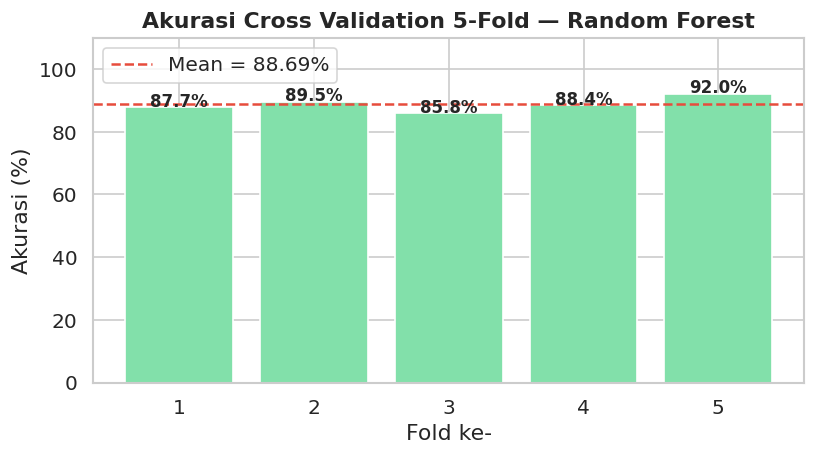

In [ ]:
# ── Cross Validation 5-Fold ───────────────────────────────────
cv_rf = cross_val_score(best_rf, X_scaled, y, cv=5, scoring='accuracy')

print(f'Cross Validation Random Forest (5-Fold):')
print(f'  Scores : {[round(s*100,2) for s in cv_rf]}%')
print(f'  Mean   : {cv_rf.mean()*100:.2f}%')
print(f'  Std    : ± {cv_rf.std()*100:.2f}%')

# Visualisasi
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 6), cv_rf*100, color='#82E0AA', edgecolor='white')
for i, v in enumerate(cv_rf*100, 1):
    ax.text(i, v+0.3, f'{v:.1f}%', ha='center',
            fontsize=10, fontweight='bold')
ax.axhline(cv_rf.mean()*100, color='#E74C3C', linestyle='--',
           linewidth=1.5, label=f'Mean = {cv_rf.mean()*100:.2f}%')
ax.set_xlabel('Fold ke-')
ax.set_ylabel('Akurasi (%)')
ax.set_title('Akurasi Cross Validation 5-Fold — Random Forest',
             fontweight='bold')
ax.legend()
ax.set_ylim(0, 110)
ax.set_xticks(range(1, 6))
plt.tight_layout()
plt.savefig('RF_04_cross_validation.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Ringkasan Hasil Random Forest ────────────────────────────
params_str = ', '.join([f'{k}={v}' for k, v in grid_rf.best_params_.items()])

print('=' * 65)
print('  RINGKASAN HASIL RANDOM FOREST')
print('  Klasifikasi Pola Aktivitas Fisik terhadap Tingkat Kebugaran')
print('=' * 65)
print(f'\n  Dataset   : {len(df)} sampel, {len(feature_cols)} fitur')
print(f'  Target    : Fitness Level (Rendah / Sedang / Tinggi)')
print(f'  Split     : 80% latih ({len(X_train_rf)}) / 20% uji ({len(X_test_rf)})')
print(f'\n  Parameter terbaik : {params_str}')
print(f'  Accuracy          : {accuracy_score(y_test_rf, y_pred_rf)*100:.2f}%')
print(f'  Precision         : {precision_score(y_test_rf, y_pred_rf, average="weighted")*100:.2f}%')
print(f'  Recall            : {recall_score(y_test_rf, y_pred_rf, average="weighted")*100:.2f}%')
print(f'  F1-Score          : {f1_score(y_test_rf, y_pred_rf, average="weighted")*100:.2f}%')
print(f'  CV 5-fold         : {cv_rf.mean()*100:.2f}% ± {cv_rf.std()*100:.2f}%')
print(f'\n📌 3 Fitur Paling Berpengaruh:')
for i, (_, r) in enumerate(
    imp_rf.sort_values('Importance', ascending=False).head(3).iterrows(), 1
):
    print(f'   {i}. {r["Fitur"]:30s}: {r["Importance"]:.4f}')
print('\n' + '=' * 65)
print('  ✅ Random Forest selesai!')
print('=' * 65)

  RINGKASAN HASIL RANDOM FOREST
  Klasifikasi Pola Aktivitas Fisik terhadap Tingkat Kebugaran

  Dataset   : 2325 sampel, 8 fitur
  Target    : Fitness Level (Rendah / Sedang / Tinggi)
  Split     : 80% latih (1860) / 20% uji (465)

  Parameter terbaik : max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=200
  Accuracy          : 85.59%
  Precision         : 86.40%
  Recall            : 85.59%
  F1-Score          : 85.79%
  CV 5-fold         : 88.69% ± 2.06%

📌 3 Fitur Paling Berpengaruh:
   1. BMI                           : 0.2388
   2. Calories_Burned               : 0.2135
   3. Session_Duration (hours)      : 0.2102

  ✅ Random Forest selesai!


PERBANDINGAN

  TABEL PERBANDINGAN — Decision Tree vs KNN vs Random Forest
  Klasifikasi Pola Aktivitas Fisik terhadap Tingkat Kebugaran


,Parameter,Accuracy (%),Precision (%),Recall (%),F1-Score (%),CV Mean (%),CV Std (%)
Model,,,,,,,
Decision Tree,"depth=13, criterion=gini",78.710000,80.120000,78.710000,79.110000,81.330000,2.250000
KNN,"K=10, metric=euclidean",91.180000,91.450000,91.180000,91.260000,93.160000,1.270000
Random Forest,"max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=200",85.590000,86.400000,85.590000,85.790000,88.690000,2.060000



🏆 Model Terbaik  : KNN
   Accuracy       : 91.18%
   F1-Score       : 91.26%
   CV Mean        : 93.16%


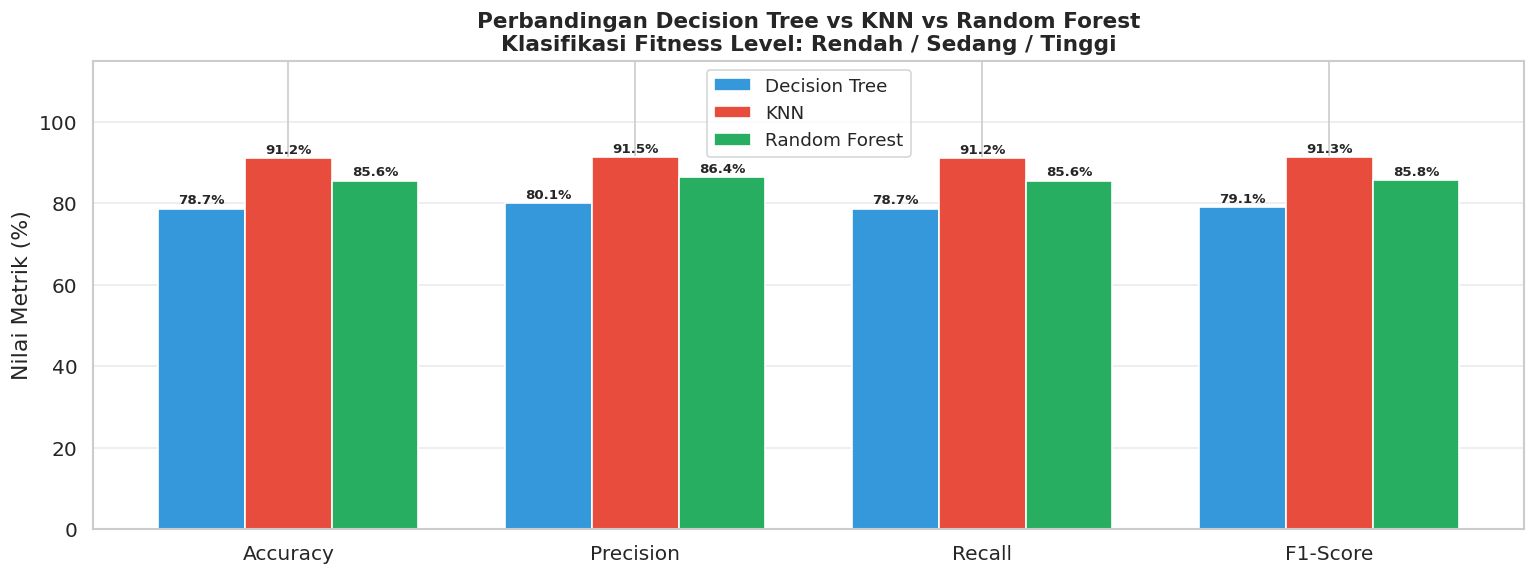

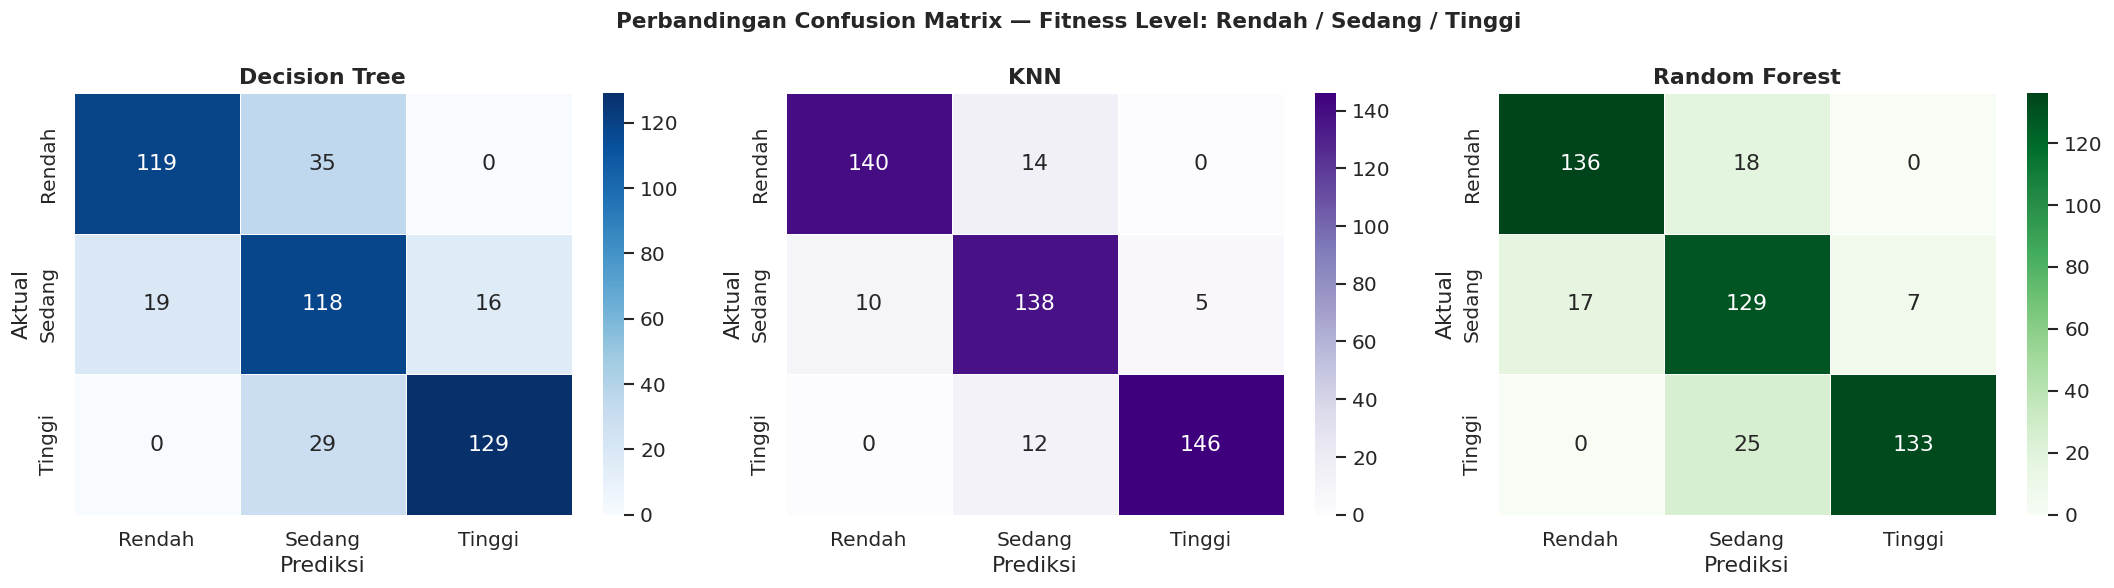

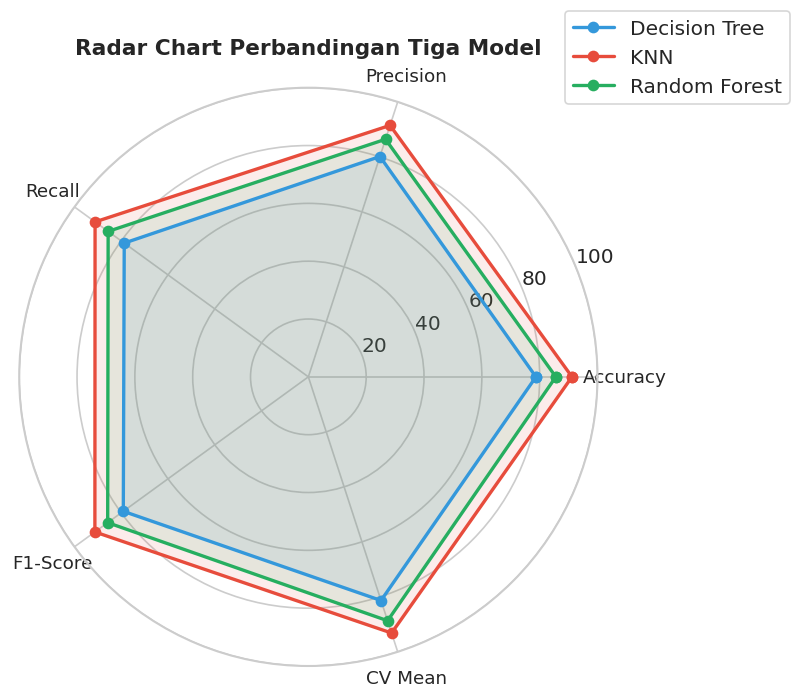

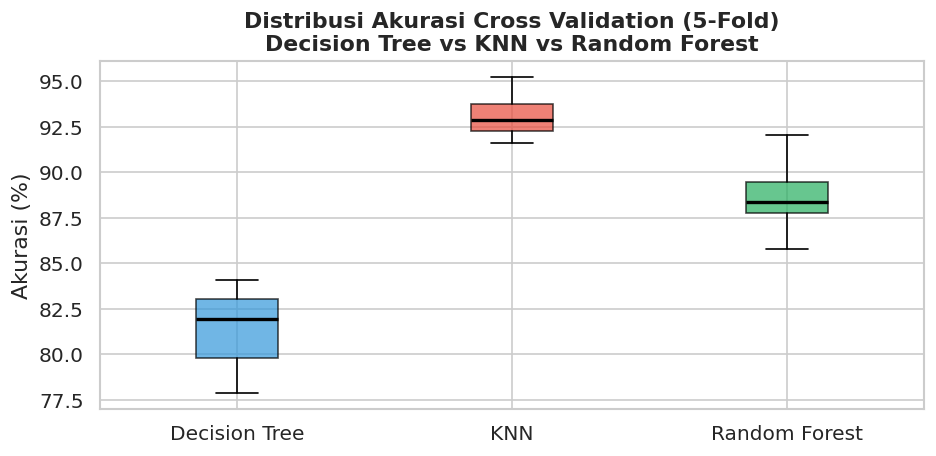


CV Decision Tree  : 81.33% ± 2.25%
CV KNN            : 93.16% ± 1.27%
CV Random Forest  : 88.69% ± 2.06%

  RINGKASAN AKHIR — PERBANDINGAN KETIGA MODEL

Model                  Accuracy  Precision     Recall   F1-Score    CV Mean
---------------------------------------------------------------------------
Decision Tree              78.71%     80.12%     78.71%     79.11%     81.33%
KNN 🏆                      91.18%     91.45%     91.18%     91.26%     93.16%
Random Forest              85.59%     86.40%     85.59%     85.79%     88.69%

🏆 Model Terbaik : KNN (F1-Score: 91.26%)

  ✅ Perbandingan selesai!


In [ ]:
# ════════════════════════════════════════════════════════════
#   TABEL PERBANDINGAN — Decision Tree vs KNN vs Random Forest
# ════════════════════════════════════════════════════════════

# ── Tabel Perbandingan Ketiga Model ──────────────────────────
hasil = pd.DataFrame([
    {
        'Model'         : 'Decision Tree',
        'Parameter'     : f'depth={grid_dt.best_params_["max_depth"]}, criterion={grid_dt.best_params_["criterion"]}',
        'Accuracy (%)'  : round(accuracy_score(y_test, y_pred_dt) * 100, 2),
        'Precision (%)' : round(precision_score(y_test, y_pred_dt, average='weighted') * 100, 2),
        'Recall (%)'    : round(recall_score(y_test, y_pred_dt, average='weighted') * 100, 2),
        'F1-Score (%)'  : round(f1_score(y_test, y_pred_dt, average='weighted') * 100, 2),
        'CV Mean (%)'   : round(cv_dt.mean() * 100, 2),
        'CV Std (%)'    : round(cv_dt.std() * 100, 2),
    },
    {
        'Model'         : 'KNN',
        'Parameter'     : f'K={grid_knn.best_params_["n_neighbors"]}, metric={grid_knn.best_params_["metric"]}',
        'Accuracy (%)'  : round(accuracy_score(y_test, y_pred_knn) * 100, 2),
        'Precision (%)' : round(precision_score(y_test, y_pred_knn, average='weighted') * 100, 2),
        'Recall (%)'    : round(recall_score(y_test, y_pred_knn, average='weighted') * 100, 2),
        'F1-Score (%)'  : round(f1_score(y_test, y_pred_knn, average='weighted') * 100, 2),
        'CV Mean (%)'   : round(cv_knn.mean() * 100, 2),
        'CV Std (%)'    : round(cv_knn.std() * 100, 2),
    },
    {
        'Model'         : 'Random Forest',
        'Parameter'     : ', '.join([f'{k}={v}' for k, v in grid_rf.best_params_.items()]),
        'Accuracy (%)'  : round(accuracy_score(y_test_rf, y_pred_rf) * 100, 2),
        'Precision (%)' : round(precision_score(y_test_rf, y_pred_rf, average='weighted') * 100, 2),
        'Recall (%)'    : round(recall_score(y_test_rf, y_pred_rf, average='weighted') * 100, 2),
        'F1-Score (%)'  : round(f1_score(y_test_rf, y_pred_rf, average='weighted') * 100, 2),
        'CV Mean (%)'   : round(cv_rf.mean() * 100, 2),
        'CV Std (%)'    : round(cv_rf.std() * 100, 2),
    }
])

print('=' * 75)
print('  TABEL PERBANDINGAN — Decision Tree vs KNN vs Random Forest')
print('  Klasifikasi Pola Aktivitas Fisik terhadap Tingkat Kebugaran')
print('=' * 75)
display(hasil.set_index('Model').style.highlight_max(
    subset=['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)', 'CV Mean (%)'],
    color='#d4f0e8'
))

# ── Tentukan model terbaik ────────────────────────────────────
best_row = hasil.loc[hasil['F1-Score (%)'].idxmax()]
print(f'\n🏆 Model Terbaik  : {best_row["Model"]}')
print(f'   Accuracy       : {best_row["Accuracy (%)"]:.2f}%')
print(f'   F1-Score       : {best_row["F1-Score (%)"]:.2f}%')
print(f'   CV Mean        : {best_row["CV Mean (%)"]:.2f}%')

# ── Bar Chart Perbandingan 4 Metrik ──────────────────────────
metrik_list = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
x     = np.arange(len(metrik_list))
w     = 0.25
warna = ['#3498DB', '#E74C3C', '#27AE60']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (_, row) in enumerate(hasil.iterrows()):
    bars = ax.bar(x + (i - 1) * w, row[metrik_list], w,
                  label=row['Model'], color=warna[i], edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.4,
                f'{bar.get_height():.1f}%',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_ylabel('Nilai Metrik (%)')
ax.set_title('Perbandingan Decision Tree vs KNN vs Random Forest\n'
             'Klasifikasi Fitness Level: Rendah / Sedang / Tinggi',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1-Score'])
ax.set_ylim(0, 115)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('COMPARE_01_bar_chart.png', bbox_inches='tight')
plt.show()

# ── Confusion Matrix Tiga Model Berdampingan ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, pred, true, title, cmap in zip(
    axes,
    [y_pred_dt,  y_pred_knn,  y_pred_rf],
    [y_test,     y_test,      y_test_rf],
    ['Decision Tree', 'KNN', 'Random Forest'],
    ['Blues',    'Purples',   'Greens']
):
    cm = confusion_matrix(true, pred, labels=LABEL_NAMES)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
                ax=ax, linewidths=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.suptitle('Perbandingan Confusion Matrix — Fitness Level: Rendah / Sedang / Tinggi',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('COMPARE_02_confusion_matrix.png', bbox_inches='tight')
plt.show()

# ── Radar Chart Perbandingan ──────────────────────────────────
kategori = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'CV Mean']
kolom    = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)', 'CV Mean (%)']
N        = len(kategori)
angles   = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for i, (_, row) in enumerate(hasil.iterrows()):
    vals = row[kolom].tolist() + [row[kolom[0]]]
    ax.plot(angles, vals, 'o-', linewidth=2,
            color=warna[i], label=row['Model'])
    ax.fill(angles, vals, alpha=0.1, color=warna[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(kategori, fontsize=11)
ax.set_ylim(0, 100)
ax.set_title('Radar Chart Perbandingan Tiga Model',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.savefig('COMPARE_03_radar_chart.png', bbox_inches='tight')
plt.show()

# ── Boxplot Cross Validation ──────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
bp = ax.boxplot(
    [cv_dt * 100, cv_knn * 100, cv_rf * 100],
    labels=['Decision Tree', 'KNN', 'Random Forest'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
for patch, color in zip(bp['boxes'], warna):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Akurasi (%)')
ax.set_title('Distribusi Akurasi Cross Validation (5-Fold)\nDecision Tree vs KNN vs Random Forest',
             fontweight='bold')
plt.tight_layout()
plt.savefig('COMPARE_04_cross_validation.png', bbox_inches='tight')
plt.show()

print(f'\nCV Decision Tree  : {cv_dt.mean()*100:.2f}% ± {cv_dt.std()*100:.2f}%')
print(f'CV KNN            : {cv_knn.mean()*100:.2f}% ± {cv_knn.std()*100:.2f}%')
print(f'CV Random Forest  : {cv_rf.mean()*100:.2f}% ± {cv_rf.std()*100:.2f}%')

# ── Ringkasan Akhir ───────────────────────────────────────────
print('\n' + '=' * 75)
print('  RINGKASAN AKHIR — PERBANDINGAN KETIGA MODEL')
print('=' * 75)
print(f'\n{"Model":<20} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1-Score":>10} {"CV Mean":>10}')
print('-' * 75)
for _, r in hasil.iterrows():
    mark = ' 🏆' if r['Model'] == best_row['Model'] else '   '
    print(f'{r["Model"] + mark:<22} {r["Accuracy (%)"] :>9.2f}% {r["Precision (%)"] :>9.2f}% {r["Recall (%)"] :>9.2f}% {r["F1-Score (%)"] :>9.2f}% {r["CV Mean (%)"] :>9.2f}%')

print(f'\n🏆 Model Terbaik : {best_row["Model"]} (F1-Score: {best_row["F1-Score (%)"]:.2f}%)')
print('\n' + '=' * 75)
print('  ✅ Perbandingan selesai!')
print('=' * 75)